In [30]:
import warnings
warnings.filterwarnings("ignore")

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Dense, Dropout, Flatten,
                                     Conv1D, MaxPooling1D, GlobalAveragePooling1D,
                                     LSTM, GRU, BatchNormalization, Softmax)
from keras.optimizers import Adam
import tensorflow as tf
import yfinance as yf
import datetime
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Modèle LSTM

In [6]:
# === 1. Récupération du ticker utilisateur ===
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

# 18 derniers mois
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date)
df = data.dropna()
df.sort_index(inplace=True)
print(df.head())

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size=50, forecast_horizon=20):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][["Open","High","Low","Close","Volume"]].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

window_size = 20
forecast_horizon = 1
num_features = 5

X, y = create_windows(df, window_size, forecast_horizon)

# === 3. Normalisation par feature ===
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# === 4. Split train/test temporel ===
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# --- Modèle LSTM ---
model_LSTM = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, num_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model_LSTM.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# === 6. Entraînement ===
history = model_LSTM.fit(X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    verbose=0)

# === 7. Prévision ===
last_window = X_scaled[-1].reshape(1, window_size, num_features)
pred_scaled = model_LSTM.predict(last_window)
pred_close = scaler_y.inverse_transform(pred_scaled)[0][0]

print(f"Prix prédit pour {ticker} dans {forecast_horizon} jours : {pred_close:.2f}")

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-11-25  26.612099  26.882662  26.587297  26.878152   85553200
2015-11-27  26.562494  26.697777  26.515146  26.670720   52185600
2015-11-30  26.672974  26.923244  26.548965  26.603077  156721200
2015-12-01  26.456528  26.787967  26.348304  26.774440  139409600
2015-12-02  26.217525  26.630134  26.172432  26.456522  133546400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
Prix prédit pour aapl dans 1 jours : 259.40


# Affichage

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


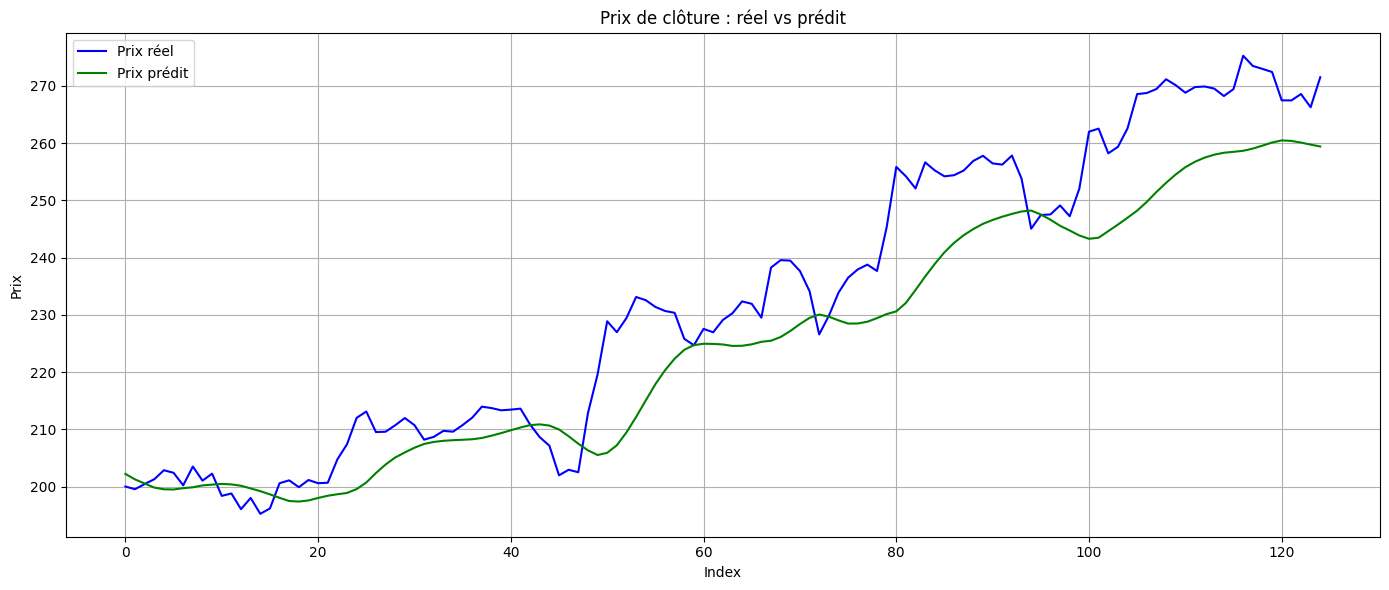

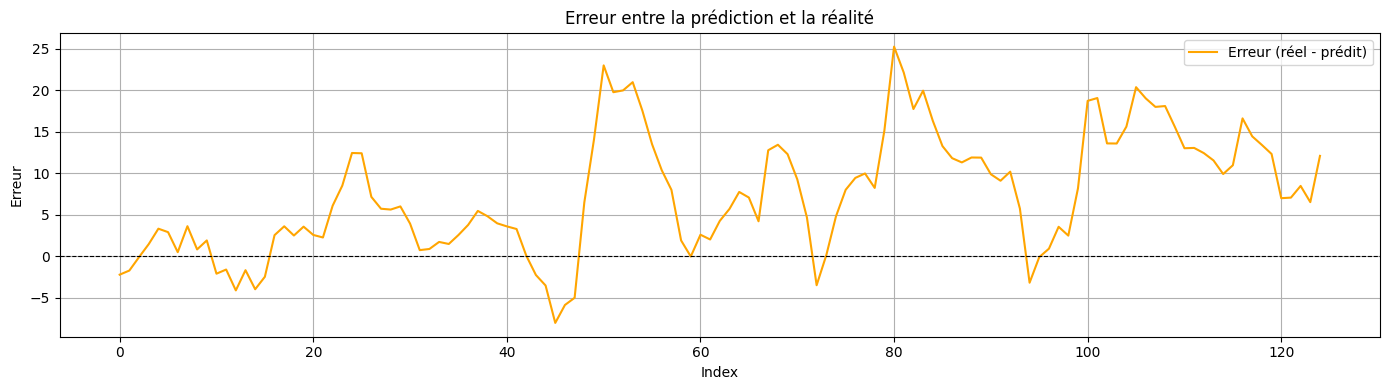

In [8]:
import matplotlib.pyplot as plt

# Prédictions
y_pred_scaled = model_LSTM.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Calcul de l'erreur
errors = y_test_real.ravel() - y_pred.ravel()

# --------- FIGURE 1 : Prix réel vs prédit ---------
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred, label="Prix prédit", color="green")
plt.title("Prix de clôture : réel vs prédit")
plt.xlabel("Index")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------- FIGURE 2 : Erreur de prédiction ---------
plt.figure(figsize=(14, 4))
plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur entre la prédiction et la réalité")
plt.xlabel("Index")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Modèle Dense

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-11-25  26.612099  26.882662  26.587297  26.878152   85553200
2015-11-27  26.562496  26.697779  26.515148  26.670722   52185600
2015-11-30  26.672977  26.923248  26.548969  26.603081  156721200
2015-12-01  26.456522  26.787962  26.348298  26.774434  139409600
2015-12-02  26.217529  26.630138  26.172436  26.456526  133546400


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,113 (102.00 KB)

 Trainable params: 26,113 (102.00 KB)

 Non-trainable params: 0 (0.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


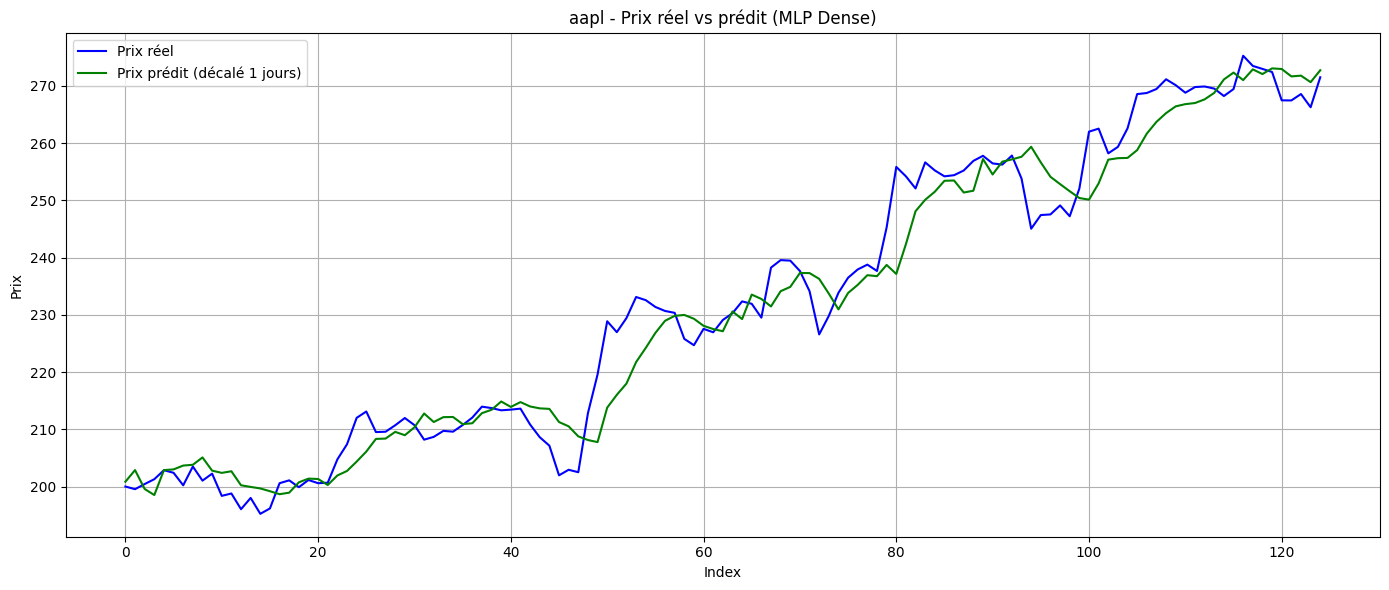

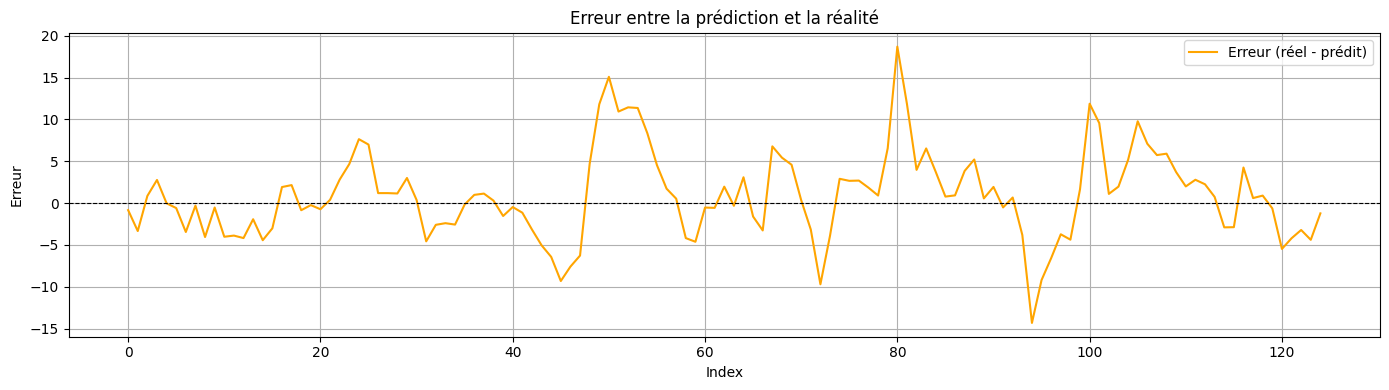

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Prix prédit pour aapl dans 1 jours : 272.71


In [38]:
# === 1. Récupération du ticker utilisateur ===
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

# x ans de données
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date)
df = data.dropna()
df.sort_index(inplace=True)
print(df.head())

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][["Open","High","Low","Close","Volume"]].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

window_size = 20       # nombre de jours d’historique
forecast_horizon = 1   # prédire le Close dans X jours
num_features = 5       # Open, High, Low, Close, Volume

X, y = create_windows(df, window_size, forecast_horizon)

# === 3. Normalisation par feature ===
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# === 4. Split train/test temporel ===
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# === 5. Modèle DENSE (MLP) ===
model = Sequential([
    Flatten(input_shape=(window_size, num_features)),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
model.summary()

# === 6. Callbacks pour meilleure convergence ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# === 7. Entraînement ===
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop, reduce_lr],
                    verbose=0)

# === 8. Prévisions sur le test set ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Décalage automatique selon forecast_horizon
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]

# === 9. Plotting ===
plt.figure(figsize=(14,6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred_aligned, label=f"Prix prédit (décalé {forecast_horizon} jours)", color="green")
plt.title(f"{ticker} - Prix réel vs prédit (MLP Dense)")
plt.xlabel("Index")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcul de l'erreur
errors = y_test_real.ravel() - y_pred_aligned.ravel()

# --------- FIGURE 2 : Erreur de prédiction ---------
plt.figure(figsize=(14, 4))
plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur entre la prédiction et la réalité")
plt.xlabel("Index")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 10. Prédiction du prochain jour ===
last_window = X_scaled[-1].reshape(1, window_size, num_features)

pred_scaled = model.predict(last_window)
pred_close = scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0][0]

print(f"Prix prédit pour {ticker} dans {forecast_horizon} jours : {pred_close:.2f}")

# ✅ 1. CNN-LSTM léger (souvent le meilleur compromis)

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-11-25  26.612099  26.882662  26.587297  26.878152   85553200
2015-11-27  26.562496  26.697779  26.515148  26.670722   52185600
2015-11-30  26.672977  26.923248  26.548969  26.603081  156721200
2015-12-01  26.456522  26.787962  26.348298  26.774434  139409600
2015-12-02  26.217529  26.630138  26.172436  26.456526  133546400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


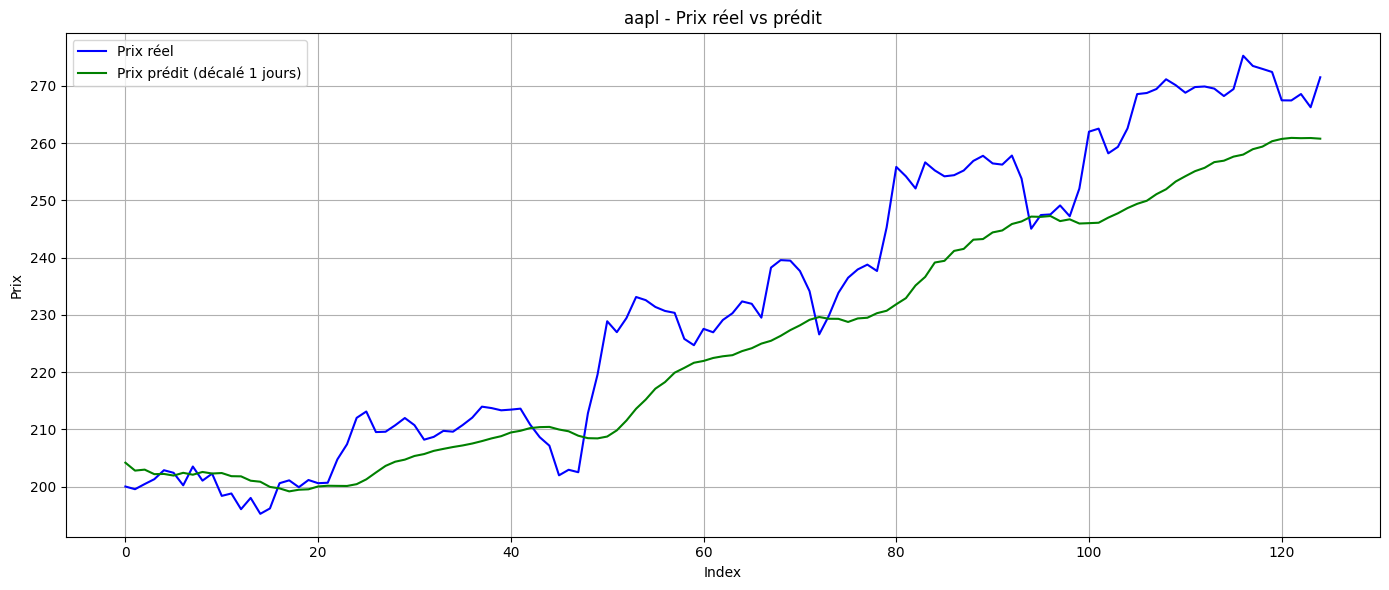

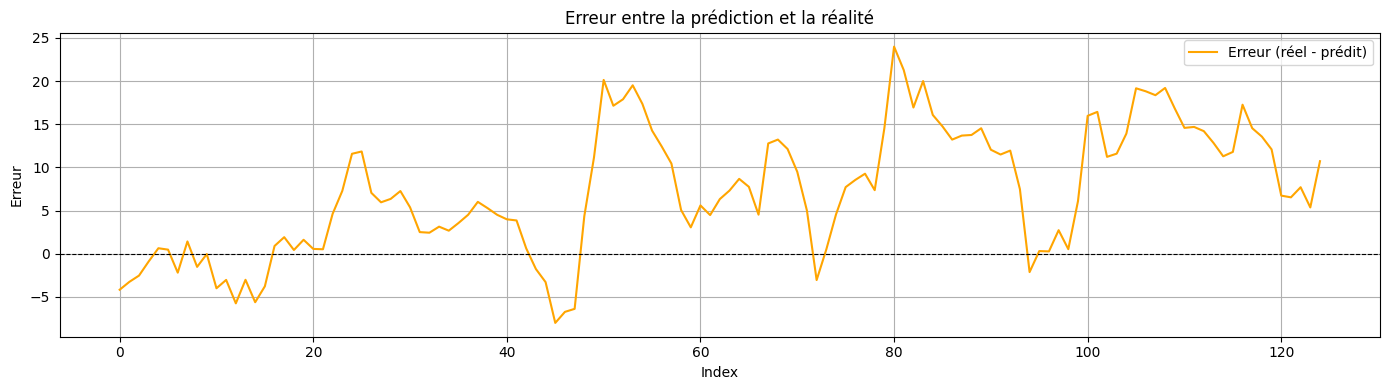

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Prix prédit pour aapl dans 1 jours : 260.76


In [42]:
# === 1. Récupération du ticker utilisateur ===
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

# x ans de données
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date)
df = data.dropna()
df.sort_index(inplace=True)
print(df.head())

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][["Open","High","Low","Close","Volume"]].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

window_size = 20       # nombre de jours d’historique
forecast_horizon = 1   # prédire le Close dans X jours
num_features = 5       # Open, High, Low, Close, Volume

X, y = create_windows(df, window_size, forecast_horizon)

# === 3. Normalisation par feature ===
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# === 4. Split train/test temporel ===
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# === 5. Modèle CNN-LSTM léger ===
model = Sequential([
    Conv1D(32, kernel_size=3, padding="same", activation="relu",
           input_shape=(window_size, num_features)),
    Conv1D(32, kernel_size=3, padding="same", activation="relu"),
    MaxPooling1D(2),

    LSTM(64, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# === 6. Callbacks pour meilleure convergence ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# === 7. Entraînement ===
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop, reduce_lr],
                    verbose=0)

# === 8. Prévisions sur le test set ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Décalage automatique selon forecast_horizon
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]

# === 9. Plotting ===
plt.figure(figsize=(14,6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred_aligned, label=f"Prix prédit (décalé {forecast_horizon} jours)", color="green")
plt.title(f"{ticker} - Prix réel vs prédit")
plt.xlabel("Index")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcul de l'erreur
errors = y_test_real.ravel() - y_pred_aligned.ravel()

# --------- FIGURE 2 : Erreur de prédiction ---------
plt.figure(figsize=(14, 4))
plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur entre la prédiction et la réalité")
plt.xlabel("Index")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 10. Prédiction du prochain jour ===
last_window = X_scaled[-1].reshape(1, window_size, num_features)
pred_scaled = model.predict(last_window)
pred_close = scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0][0]

print(f"Prix prédit pour {ticker} dans {forecast_horizon} jours : {pred_close:.2f}")

# ✅ 2. CNN pur (ultra simple mais étonnamment performant)

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-11-25  26.612099  26.882662  26.587297  26.878152   85553200
2015-11-27  26.562496  26.697779  26.515148  26.670722   52185600
2015-11-30  26.672977  26.923248  26.548969  26.603081  156721200
2015-12-01  26.456522  26.787962  26.348298  26.774434  139409600
2015-12-02  26.217529  26.630138  26.172436  26.456526  133546400
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


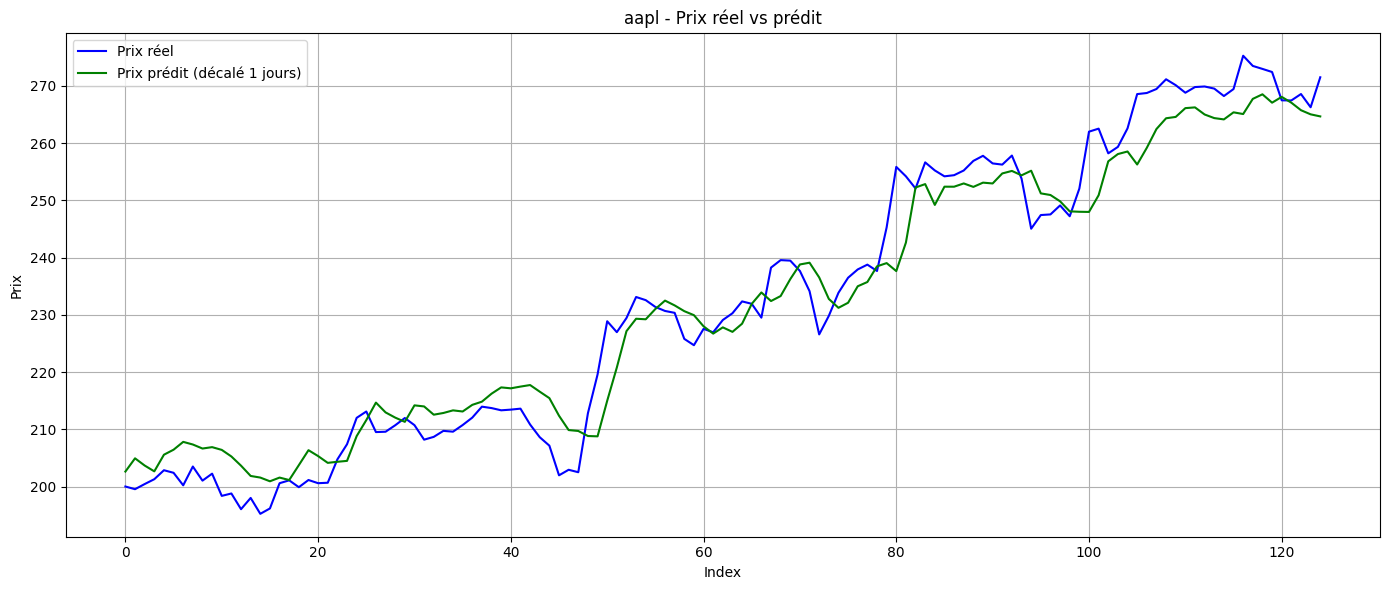

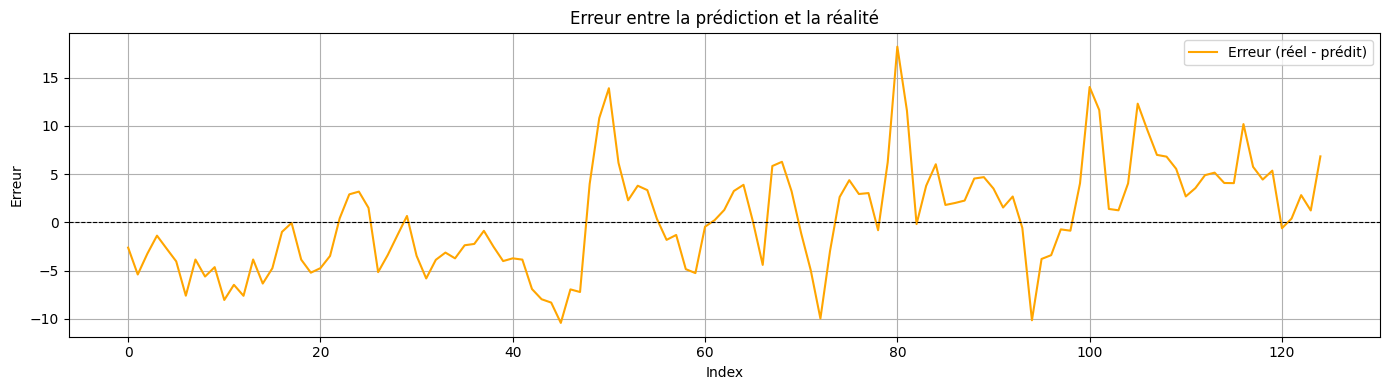

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
Prix prédit pour aapl dans 1 jours : 264.65


In [43]:
# === 1. Récupération du ticker utilisateur ===
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

# x ans de données
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date)
df = data.dropna()
df.sort_index(inplace=True)
print(df.head())

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][["Open","High","Low","Close","Volume"]].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

window_size = 20       # nombre de jours d’historique
forecast_horizon = 1   # prédire le Close dans X jours
num_features = 5       # Open, High, Low, Close, Volume

X, y = create_windows(df, window_size, forecast_horizon)

# === 3. Normalisation par feature ===
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# === 4. Split train/test temporel ===
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# === 5. Modèle CNN simple ===
model = Sequential([
    Conv1D(64, 5, padding='same', activation='relu',
           input_shape=(window_size, num_features)),
    BatchNormalization(),

    Conv1D(64, 5, padding='same', activation='relu'),
    BatchNormalization(),

    GlobalAveragePooling1D(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# === 6. Callbacks pour meilleure convergence ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# === 7. Entraînement ===
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop, reduce_lr],
                    verbose=0)

# === 8. Prévisions sur le test set ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Décalage automatique selon forecast_horizon
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]

# === 9. Plotting ===
plt.figure(figsize=(14,6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred_aligned, label=f"Prix prédit (décalé {forecast_horizon} jours)", color="green")
plt.title(f"{ticker} - Prix réel vs prédit")
plt.xlabel("Index")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcul de l'erreur
errors = y_test_real.ravel() - y_pred_aligned.ravel()

# --------- FIGURE 2 : Erreur de prédiction ---------
plt.figure(figsize=(14, 4))
plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur entre la prédiction et la réalité")
plt.xlabel("Index")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 10. Prédiction du prochain jour ===
last_window = X_scaled[-1].reshape(1, window_size, num_features)
pred_scaled = model.predict(last_window)
pred_close = scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0][0]

print(f"Prix prédit pour {ticker} dans {forecast_horizon} jours : {pred_close:.2f}")

# ✅ 3. LSTM + Attention (version très légère du gros modèle)

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-11-25  26.612099  26.882662  26.587297  26.878152   85553200
2015-11-27  26.562496  26.697779  26.515148  26.670722   52185600
2015-11-30  26.672977  26.923248  26.548969  26.603081  156721200
2015-12-01  26.456522  26.787962  26.348298  26.774434  139409600
2015-12-02  26.217529  26.630138  26.172436  26.456526  133546400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


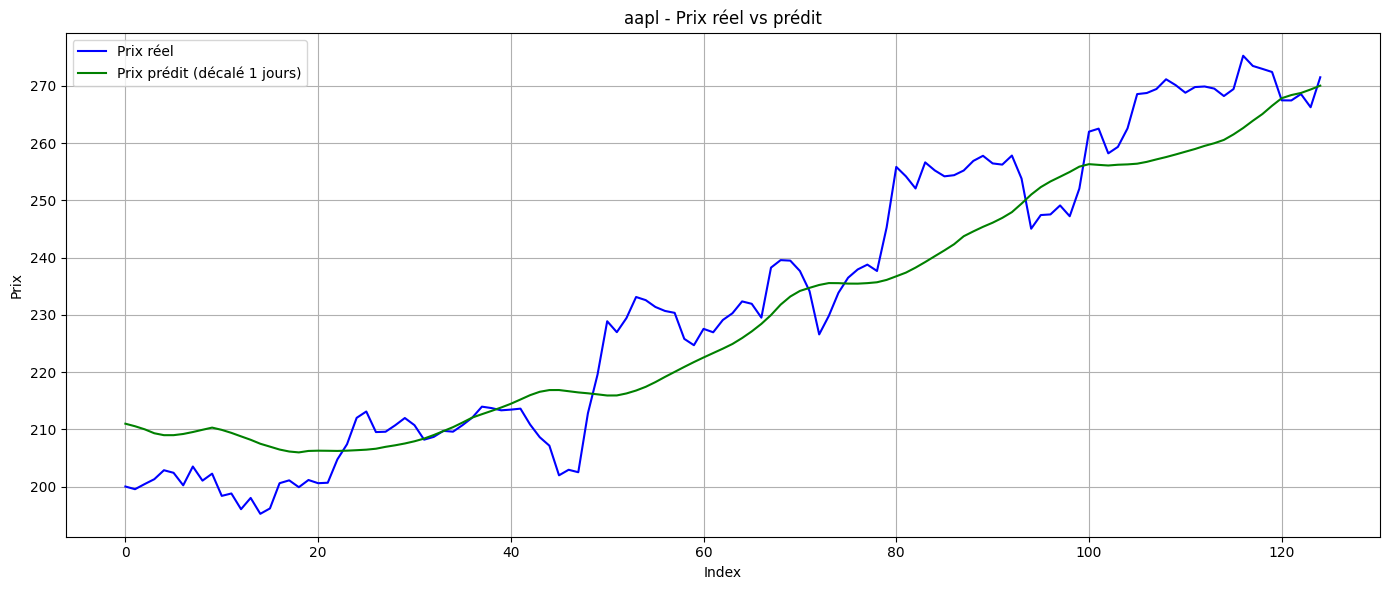

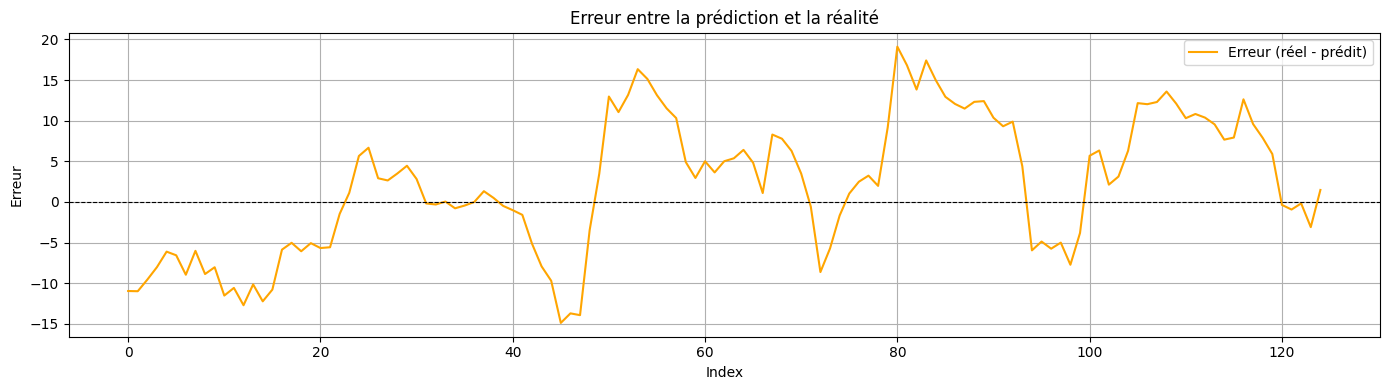

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prix prédit pour aapl dans 1 jours : 270.02


In [46]:
from tensorflow.keras.layers import Lambda

# === 1. Récupération du ticker utilisateur ===
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

# x ans de données
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date)
df = data.dropna()
df.sort_index(inplace=True)
print(df.head())

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][["Open","High","Low","Close","Volume"]].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

window_size = 20       # nombre de jours d’historique
forecast_horizon = 1   # prédire le Close dans X jours
num_features = 5       # Open, High, Low, Close, Volume

X, y = create_windows(df, window_size, forecast_horizon)

# === 3. Normalisation par feature ===
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# === 4. Split train/test temporel ===
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# === 5. Modèle LSTM + Mini-Attention ===
inp = Input(shape=(window_size, num_features))

x = LSTM(64, return_sequences=True)(inp)
x = Dropout(0.2)(x)

# Mini-attention
score = Dense(1, activation='tanh')(x)
weights = Softmax(axis=1)(score)

context = Lambda(lambda z: tf.reduce_sum(z[0] * z[1], axis=1))([weights, x])

x = Dense(32, activation='relu')(context)
x = Dropout(0.2)(x)
out = Dense(1)(x)

model = Model(inputs=inp, outputs=out)

model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# === 6. Callbacks pour meilleure convergence ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# === 7. Entraînement ===
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop, reduce_lr],
                    verbose=0)

# === 8. Prévisions sur le test set ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Décalage automatique selon forecast_horizon
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]

# === 9. Plotting ===
plt.figure(figsize=(14,6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred_aligned, label=f"Prix prédit (décalé {forecast_horizon} jours)", color="green")
plt.title(f"{ticker} - Prix réel vs prédit")
plt.xlabel("Index")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcul de l'erreur
errors = y_test_real.ravel() - y_pred_aligned.ravel()

# --------- FIGURE 2 : Erreur de prédiction ---------
plt.figure(figsize=(14, 4))
plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur entre la prédiction et la réalité")
plt.xlabel("Index")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 10. Prédiction du prochain jour ===
last_window = X_scaled[-1].reshape(1, window_size, num_features)
pred_scaled = model.predict(last_window)
pred_close = scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0][0]

print(f"Prix prédit pour {ticker} dans {forecast_horizon} jours : {pred_close:.2f}")

# ✅ 4. GRU + CNN (très efficace sur séries financières)

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-11-25  26.612099  26.882662  26.587297  26.878152   85553200
2015-11-27  26.562496  26.697779  26.515148  26.670722   52185600
2015-11-30  26.672977  26.923248  26.548969  26.603081  156721200
2015-12-01  26.456522  26.787962  26.348298  26.774434  139409600
2015-12-02  26.217529  26.630138  26.172436  26.456526  133546400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


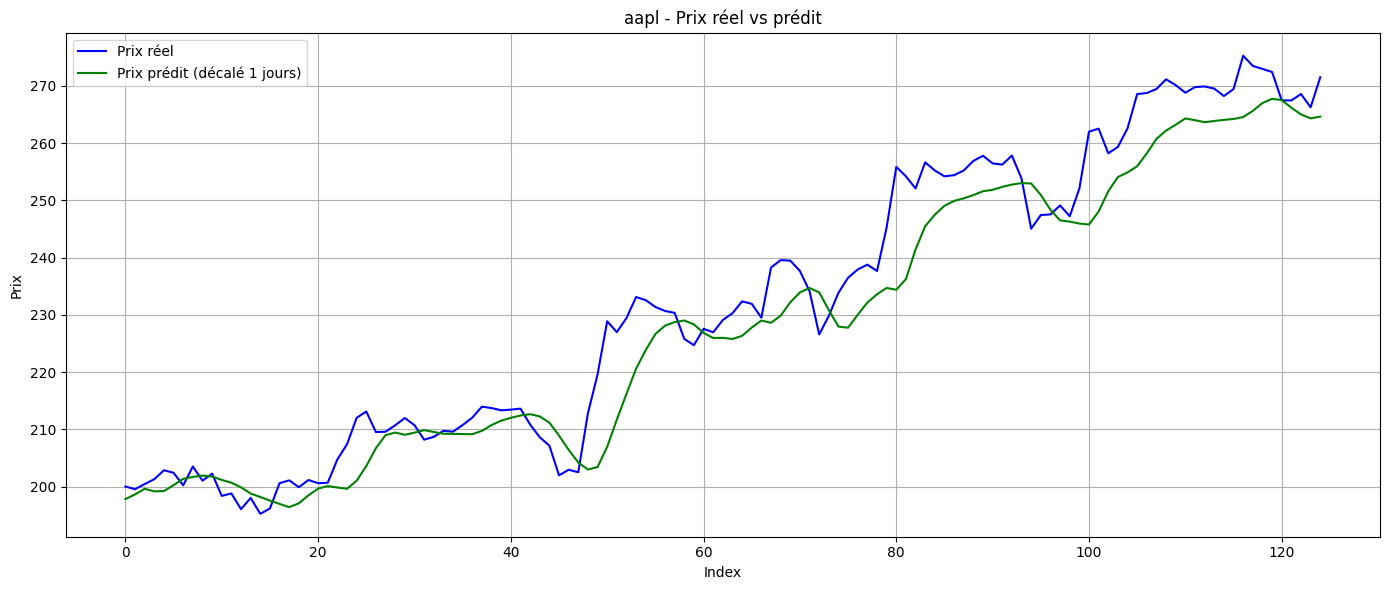

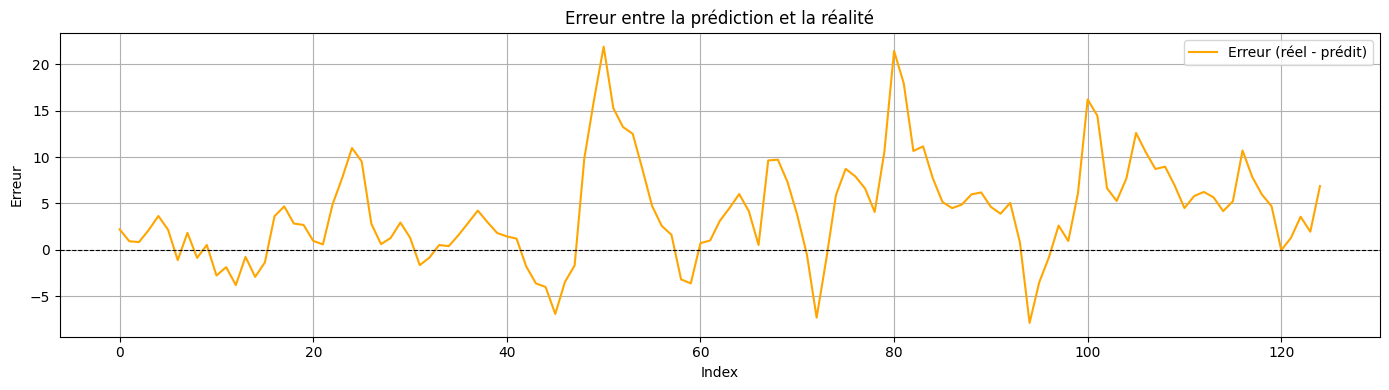

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Prix prédit pour aapl dans 1 jours : 264.62


In [45]:
# === 1. Récupération du ticker utilisateur ===
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

# x ans de données
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date)
df = data.dropna()
df.sort_index(inplace=True)
print(df.head())

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][["Open","High","Low","Close","Volume"]].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

window_size = 20       # nombre de jours d’historique
forecast_horizon = 1   # prédire le Close dans X jours
num_features = 5       # Open, High, Low, Close, Volume

X, y = create_windows(df, window_size, forecast_horizon)

# === 3. Normalisation par feature ===
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# === 4. Split train/test temporel ===
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# === 5. Modèle GRU + CNN ===
model = Sequential([
    Conv1D(32, 3, padding='same', activation='relu',
           input_shape=(window_size, num_features)),

    GRU(64, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# === 6. Callbacks pour meilleure convergence ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# === 7. Entraînement ===
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop, reduce_lr],
                    verbose=0)

# === 8. Prévisions sur le test set ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Décalage automatique selon forecast_horizon
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]

# === 9. Plotting ===
plt.figure(figsize=(14,6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred_aligned, label=f"Prix prédit (décalé {forecast_horizon} jours)", color="green")
plt.title(f"{ticker} - Prix réel vs prédit")
plt.xlabel("Index")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcul de l'erreur
errors = y_test_real.ravel() - y_pred_aligned.ravel()

# --------- FIGURE 2 : Erreur de prédiction ---------
plt.figure(figsize=(14, 4))
plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur entre la prédiction et la réalité")
plt.xlabel("Index")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 10. Prédiction du prochain jour ===
last_window = X_scaled[-1].reshape(1, window_size, num_features)
pred_scaled = model.predict(last_window)
pred_close = scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0][0]

print(f"Prix prédit pour {ticker} dans {forecast_horizon} jours : {pred_close:.2f}")

# Modèle GRU

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-11-25  26.612099  26.882662  26.587297  26.878152   85553200
2015-11-27  26.562496  26.697779  26.515148  26.670722   52185600
2015-11-30  26.672977  26.923248  26.548969  26.603081  156721200
2015-12-01  26.456522  26.787962  26.348298  26.774434  139409600
2015-12-02  26.217529  26.630138  26.172436  26.456526  133546400


I0000 00:00:1763823652.693551      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763823652.694245      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1763823657.039002     107 cuda_dnn.cc:529] Loaded cuDNN version 90300


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


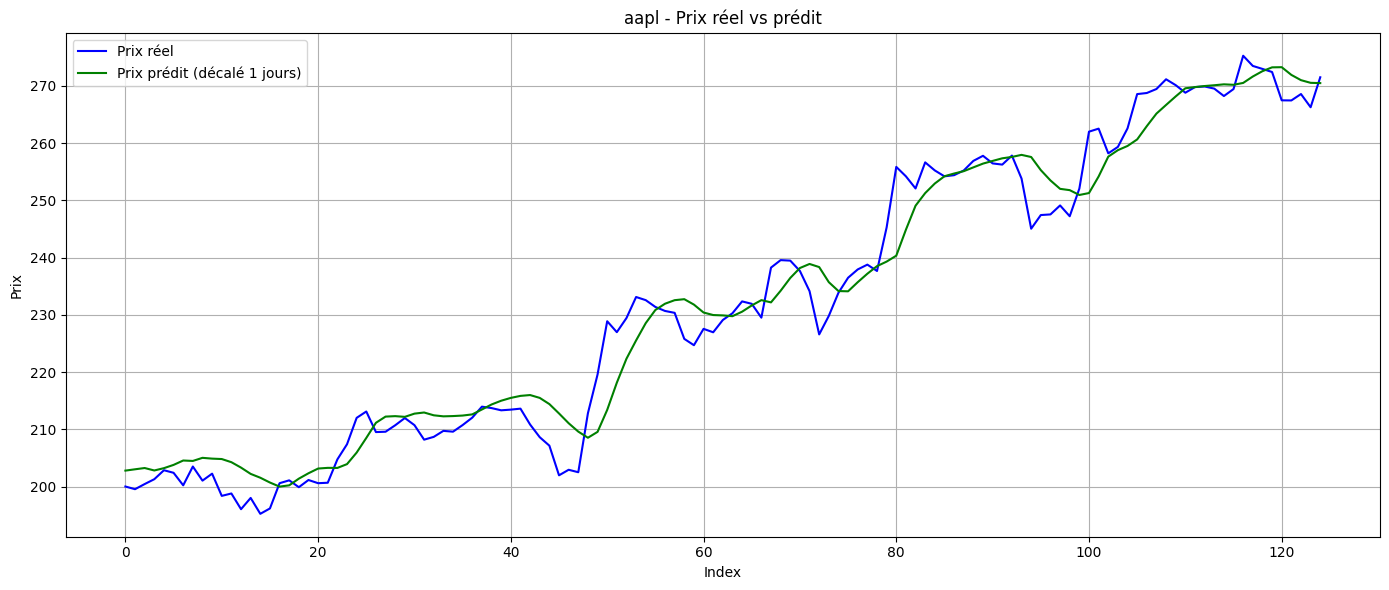

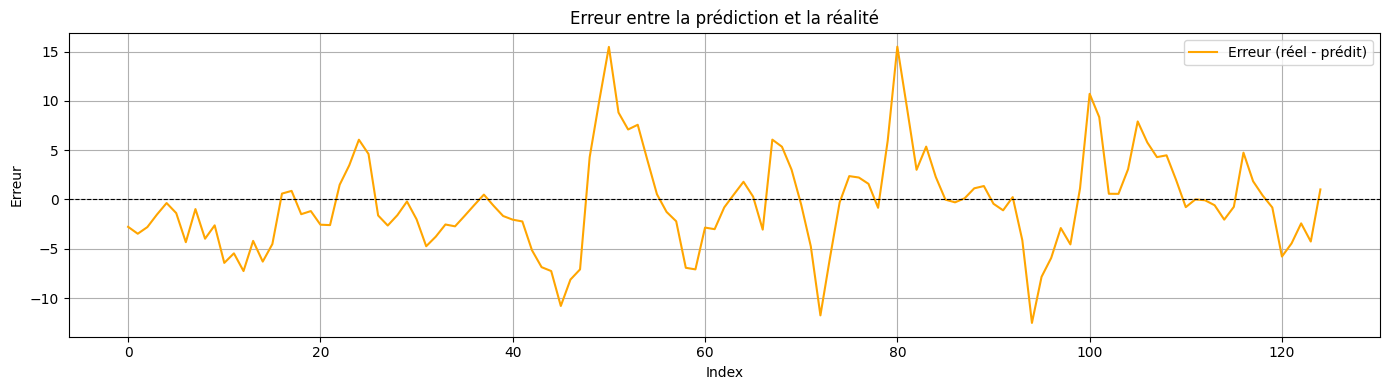

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prix prédit pour aapl dans 1 jours : 270.47


In [3]:
# === 1. Récupération du ticker utilisateur ===
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

# x ans de données
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date)
df = data.dropna()
df.sort_index(inplace=True)
print(df.head())

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][["Open","High","Low","Close","Volume"]].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

window_size = 20       # nombre de jours d’historique
forecast_horizon = 1   # prédire le Close dans X jours
num_features = 5       # Open, High, Low, Close, Volume

X, y = create_windows(df, window_size, forecast_horizon)

# === 3. Normalisation par feature ===
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# === 4. Split train/test temporel ===
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# === 5. Modèle GRU optimisé (2 couches) ===
model = Sequential([
    GRU(128, return_sequences=True, input_shape=(window_size, num_features)),
    Dropout(0.2),
    GRU(64),  # dernière GRU, return_sequences=False
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# === 6. Callbacks pour meilleure convergence ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# === 7. Entraînement ===
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop, reduce_lr],
                    verbose=0)

# === 8. Prévisions sur le test set ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Décalage automatique selon forecast_horizon
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]

# === 9. Plotting ===
plt.figure(figsize=(14,6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred_aligned, label=f"Prix prédit (décalé {forecast_horizon} jours)", color="green")
plt.title(f"{ticker} - Prix réel vs prédit")
plt.xlabel("Index")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcul de l'erreur
errors = y_test_real.ravel() - y_pred_aligned.ravel()

# --------- FIGURE 2 : Erreur de prédiction ---------
plt.figure(figsize=(14, 4))
plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur entre la prédiction et la réalité")
plt.xlabel("Index")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 10. Prédiction du prochain jour ===
last_window = X_scaled[-1].reshape(1, window_size, num_features)
pred_scaled = model.predict(last_window)
pred_close = scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0][0]

print(f"Prix prédit pour {ticker} dans {forecast_horizon} jours : {pred_close:.2f}")

# GRU 2
# Même chose qu'avant mais en ajoutant des données intéressantes au dataset pour améliorer l'étude des petites variations

C'est une version sans prédiction récursive (on utilise des données réelles pour former les windows et on prédit jour par jour)

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-11-25  26.612099  26.882662  26.587297  26.878152   85553200
2015-11-27  26.562496  26.697779  26.515148  26.670722   52185600
2015-11-30  26.672977  26.923248  26.548969  26.603081  156721200
2015-12-01  26.456522  26.787962  26.348298  26.774434  139409600
2015-12-02  26.217529  26.630138  26.172436  26.456526  133546400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


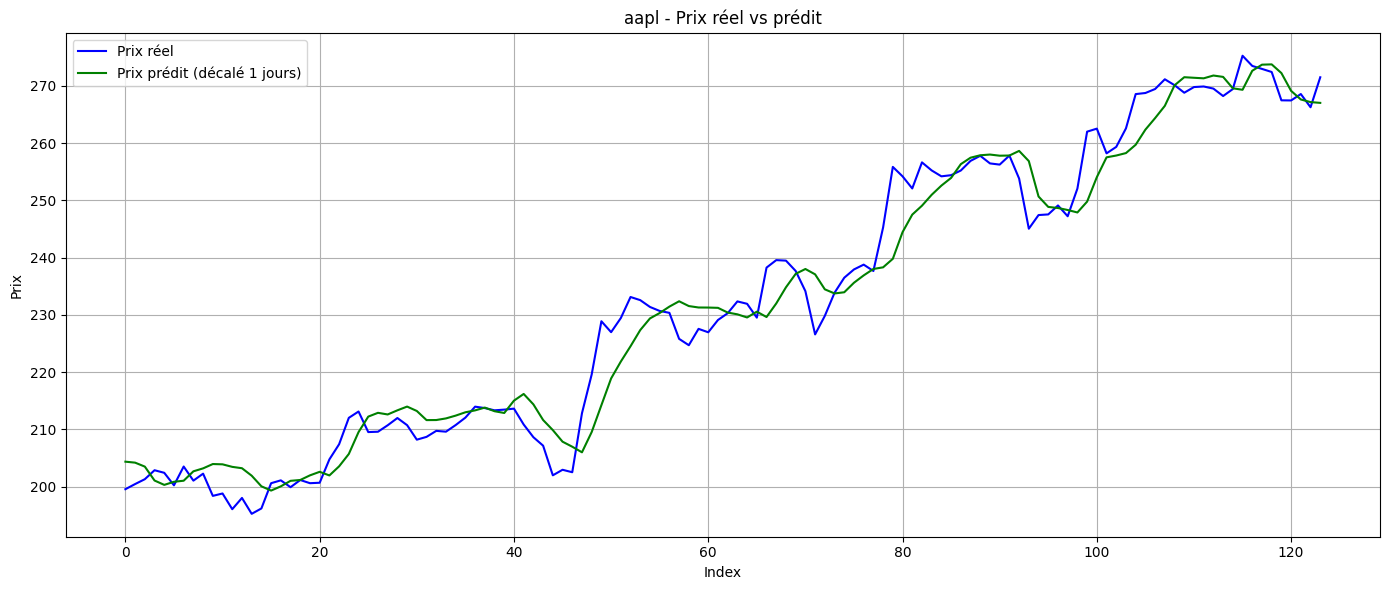

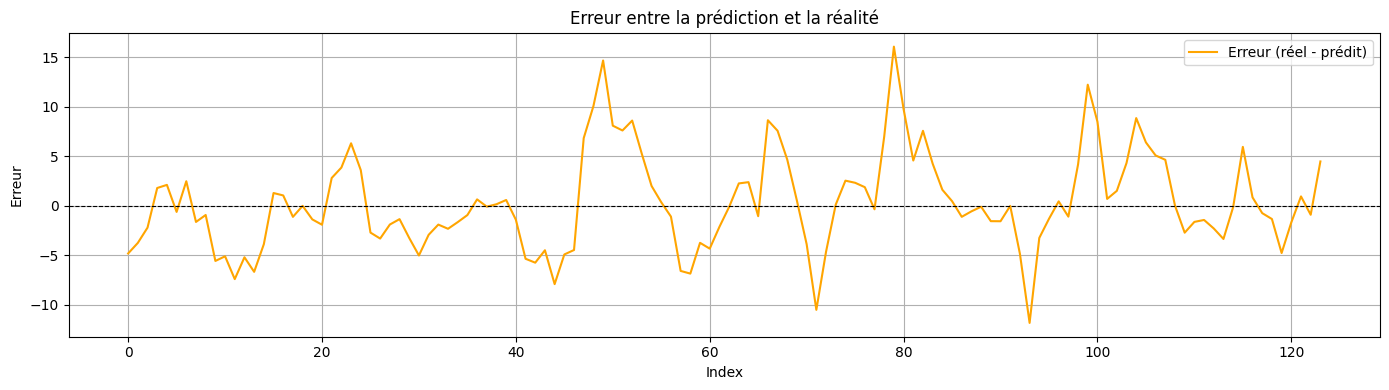

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prix prédit pour aapl dans 1 jours : 267.02


In [4]:
# === 1. Récupération du ticker utilisateur ===
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

# x ans de données
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date)
df = data.dropna()
df.sort_index(inplace=True)
print(df.head())

# === 1b. Ajout des indicateurs techniques ===
# SMA sur 10 jours
df['SMA_10'] = df['Close'].rolling(10).mean()
# EMA sur 10 jours
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
# RSI sur 14 jours
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df['RSI_14'] = 100 - (100 / (1 + RS))

df.dropna(inplace=True)  # supprimer les lignes avec NaN dues aux indicateurs

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size, forecast_horizon, feature_cols):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][feature_cols].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

feature_cols = ["Open","High","Low","Close","Volume","SMA_10","EMA_10","RSI_14"]
num_features = len(feature_cols)
window_size = 20       # nombre de jours d’historique
forecast_horizon = 1   # prédire le Close dans X jours

X, y = create_windows(df, window_size, forecast_horizon, feature_cols)

# === 3. Normalisation par feature ===
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# === 4. Split train/test temporel ===
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# === 5. Modèle GRU optimisé (2 couches) ===
model = Sequential([
    GRU(128, return_sequences=True, input_shape=(window_size, num_features)),
    Dropout(0.2),
    GRU(64),  # dernière GRU, return_sequences=False
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# === 6. Callbacks pour meilleure convergence ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# === 7. Entraînement ===
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop, reduce_lr],
                    verbose=0)

# === 8. Prévisions sur le test set ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Décalage automatique selon forecast_horizon
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]

# === 9. Plotting ===
plt.figure(figsize=(14,6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred_aligned, label=f"Prix prédit (décalé {forecast_horizon} jours)", color="green")
plt.title(f"{ticker} - Prix réel vs prédit")
plt.xlabel("Index")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcul de l'erreur
errors = y_test_real.ravel() - y_pred_aligned.ravel()

# --------- FIGURE 2 : Erreur de prédiction ---------
plt.figure(figsize=(14, 4))
plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur entre la prédiction et la réalité")
plt.xlabel("Index")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 10. Prédiction du prochain jour ===
last_window = X_scaled[-1].reshape(1, window_size, num_features)
pred_scaled = model.predict(last_window)
pred_close = scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0][0]

print(f"Prix prédit pour {ticker} dans {forecast_horizon} jours : {pred_close:.2f}")

In [ ]:
import joblib

# Sauvegarde du modèle GRU
model.save("modele_gru_v2.h5")

# Sauvegarde des scalers
joblib.dump(scalers_X, "scalers_X_v2.pkl")
joblib.dump(scaler_y, "scaler_y_v2.pkl")

print(scalers_X)
print(scaler_y)

# Même qu'avant mais récusrif pour pouvoir prédire sans avoir les données pour les windows

Spoiler : ça pue la merde

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


[*********************100%***********************]  1 of 1 completed


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


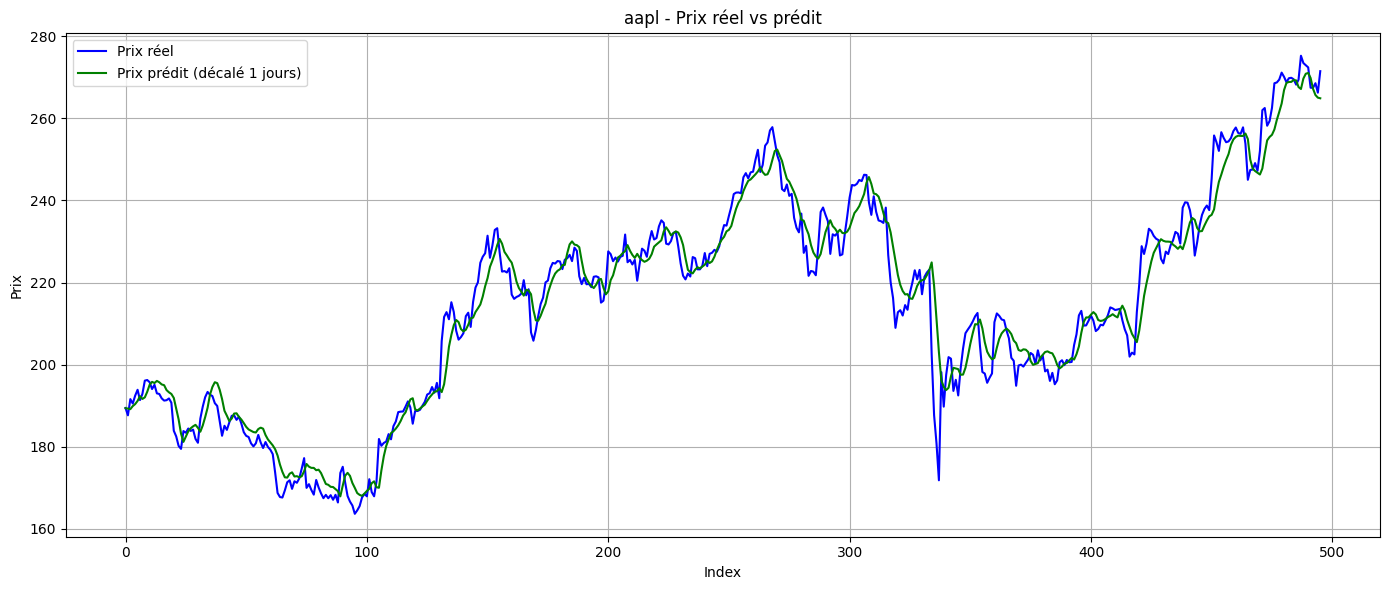

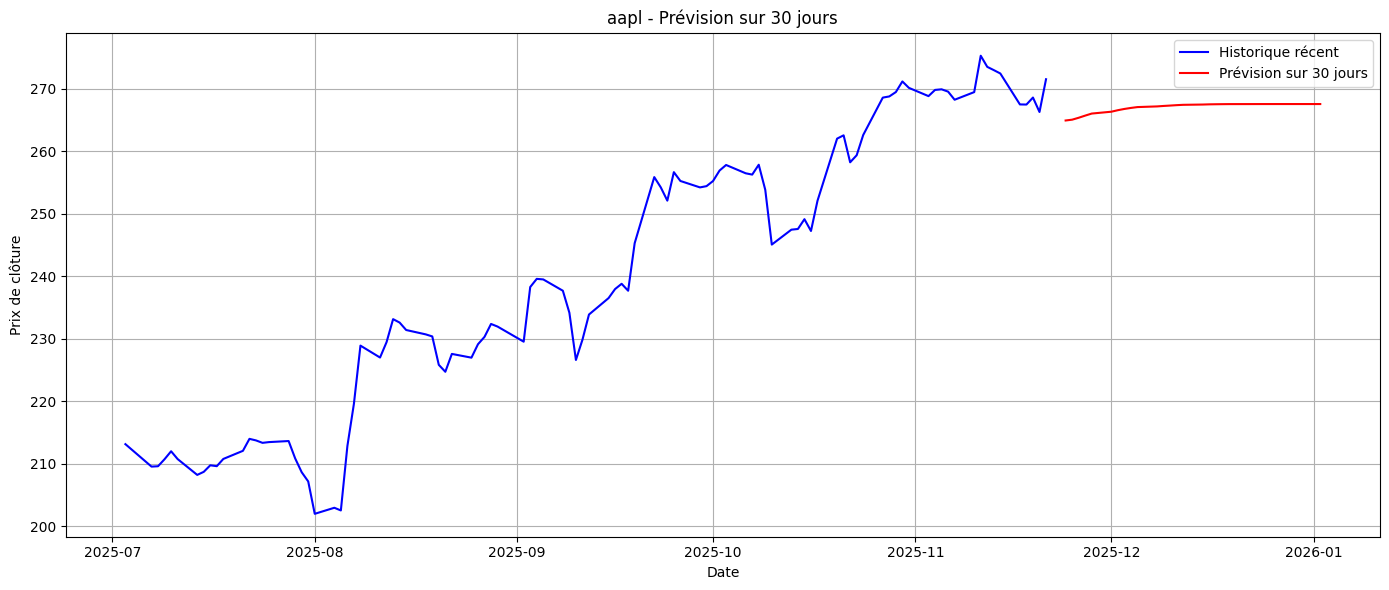

Prix prédit pour aapl dans 30 jours : 267.52


In [5]:
import numpy as np
import pandas as pd
import datetime
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# === 1. Récupération du ticker utilisateur ===
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

# 10 ans de données
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date)
df = data.dropna()
df.sort_index(inplace=True)

# === 1b. Ajout des indicateurs techniques ===
# SMA sur 10 jours
df['SMA_10'] = df['Close'].rolling(10).mean()
# EMA sur 10 jours
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
# RSI sur 14 jours
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df['RSI_14'] = 100 - (100 / (1 + RS))

df.dropna(inplace=True)  # supprimer les lignes avec NaN dues aux indicateurs

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size=50, forecast_horizon=1, feature_cols=None):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][feature_cols].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

feature_cols = ["Open","High","Low","Close","Volume","SMA_10","EMA_10","RSI_14"]
num_features = len(feature_cols)
window_size = 20
forecast_horizon = 1

X, y = create_windows(df, window_size, forecast_horizon, feature_cols)

#print(X)
#print(y)

# === 3. Normalisation par feature ===
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    #print(scalers_X[i])
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])
    #print(f"Voici le tour {i}",X_scaled[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# === 4. Split train/test temporel ===
split = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# === 5. Modèle GRU optimisé (2 couches) ===
model = Sequential([
    GRU(128, return_sequences=True, input_shape=(window_size, num_features)),
    Dropout(0.2),
    GRU(64),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# === 6. Callbacks pour meilleure convergence ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# === 7. Entraînement ===
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop, reduce_lr],
                    verbose=0)

# === 8. Prévisions sur le test set ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Décalage automatique selon forecast_horizon
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]

# === 9. Plotting ===
plt.figure(figsize=(14,6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred_aligned, label=f"Prix prédit (décalé {forecast_horizon} jours)", color="green")
plt.title(f"{ticker} - Prix réel vs prédit")
plt.xlabel("Index")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 10. Prédiction multi-step récursive ===
forecast_days = 30  # Nombre de jours à prédire
current_window = X_scaled[-1].reshape(1, window_size, num_features)
predictions_scaled = []

for i in range(forecast_days):
    # 1️⃣ Prédiction du jour suivant
    pred_scaled = model.predict(current_window, verbose=0)[0, 0]
    predictions_scaled.append(pred_scaled)

    # 2️⃣ Création de la nouvelle ligne
    new_row = current_window[0, -1, :].copy()  # on copie la dernière ligne
    new_row[3] = pred_scaled                  # remplacer la colonne "Close" par la prédiction

    # 3️⃣ Décalage de la fenêtre
    next_window = np.vstack([current_window[0, 1:, :], new_row])
    current_window = next_window.reshape(1, window_size, num_features)

# 4️⃣ Conversion des prédictions en valeurs réelles
predictions = scaler_y.inverse_transform(np.array(predictions_scaled).reshape(-1,1)).flatten()

# 5️⃣ Génération des dates futures (jours ouvrés)
last_date = df.index[-1]
forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)

# 6️⃣ Affichage
plt.figure(figsize=(14,6))
plt.plot(df.index[-100:], df["Close"].values[-100:], label="Historique récent", color="blue")
plt.plot(forecast_dates, predictions, label=f"Prévision sur {forecast_days} jours", color="red")
plt.title(f"{ticker} - Prévision sur {forecast_days} jours")
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 7️⃣ Dernière valeur prédite
print(f"Prix prédit pour {ticker} dans {forecast_days} jours : {predictions[-1]:.2f}")

# Essayer de prédire pas qu'à un jour

Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD):  aapl


[*********************100%***********************]  1 of 1 completed


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


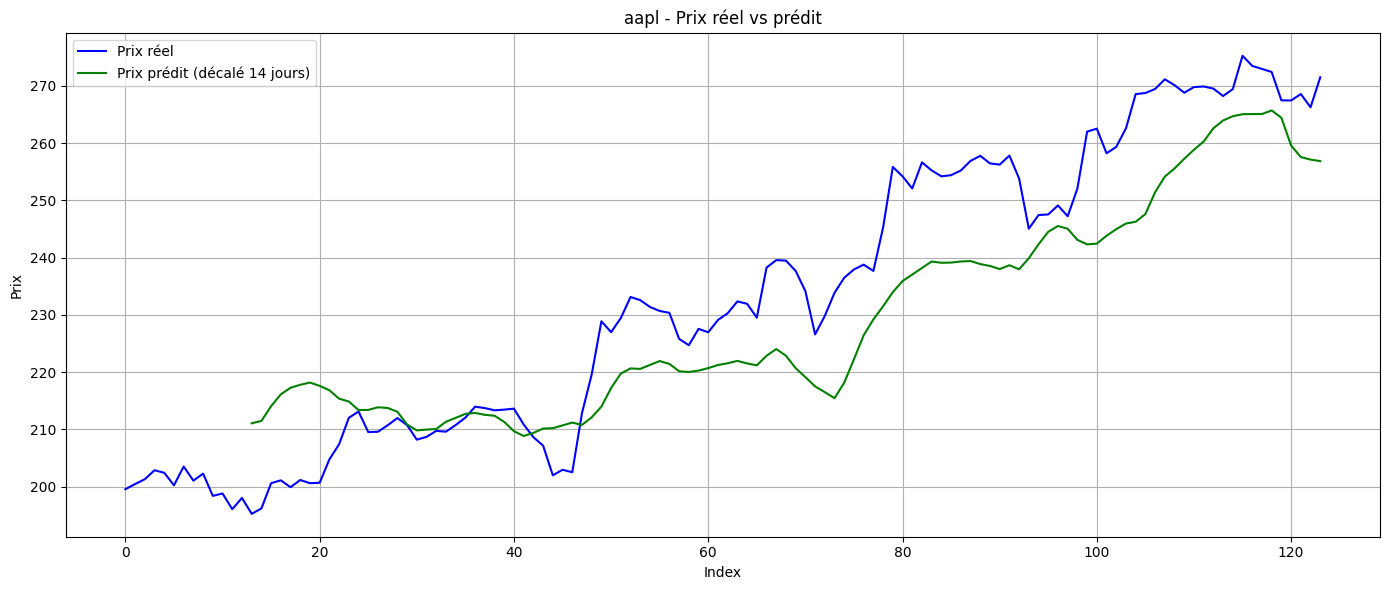

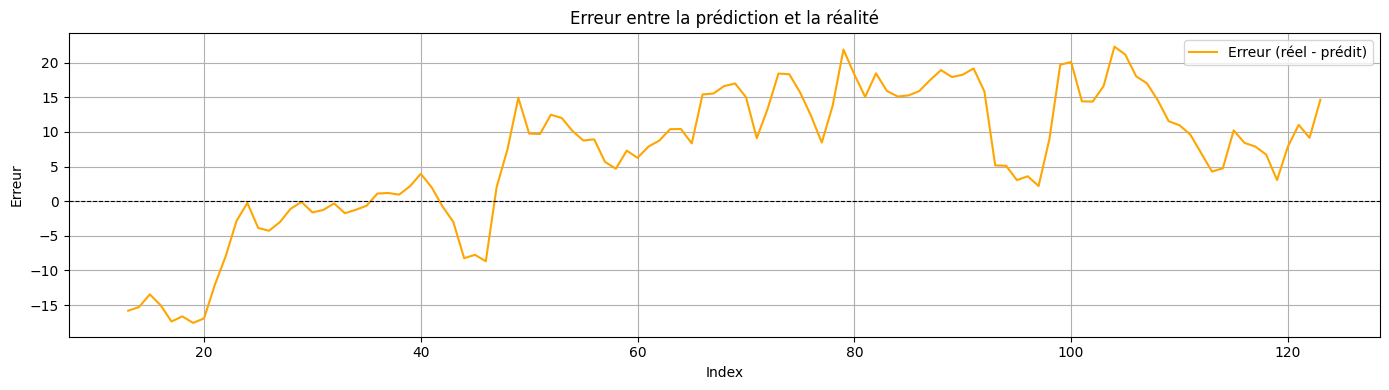

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Prix prédit pour aapl dans 14 jours : 278.08


In [11]:
import numpy as np
import pandas as pd
import datetime
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# === 1. Récupération du ticker utilisateur ===
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

# 10 ans de données
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date)
df = data.dropna()
df.sort_index(inplace=True)

# === 1b. Ajout des indicateurs techniques ===
# SMA sur 10 jours
df['SMA_10'] = df['Close'].rolling(10).mean()
# EMA sur 10 jours
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
# RSI sur 14 jours
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df['RSI_14'] = 100 - (100 / (1 + RS))

df.dropna(inplace=True)  # supprimer les lignes avec NaN dues aux indicateurs

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size=50, forecast_horizon=1, feature_cols=None):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][feature_cols].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

feature_cols = ["Open","High","Low","Close","Volume","SMA_10","EMA_10","RSI_14"]
num_features = len(feature_cols)
window_size = 20
forecast_horizon = 14

X, y = create_windows(df, window_size, forecast_horizon, feature_cols)

#print(X)
#print(y)

# === 3. Normalisation par feature ===
X_scaled = np.zeros_like(X)
scalers_X = {}
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    #print(scalers_X[i])
    X_scaled[:,:,i] = scalers_X[i].fit_transform(X[:,:,i])
    #print(f"Voici le tour {i}",X_scaled[:,:,i])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1,1))

# === 4. Split train/test temporel ===
split = int(0.95 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# === 5. Modèle GRU optimisé (2 couches) ===
model = Sequential([
    GRU(128, return_sequences=True, input_shape=(window_size, num_features)),
    Dropout(0.2),
    GRU(64),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# === 6. Callbacks pour meilleure convergence ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# === 7. Entraînement ===
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop, reduce_lr],
                    verbose=0)

# === 8. Prévisions sur le test set ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Alignement correct selon forecast_horizon
y_pred_aligned = np.full_like(y_test_real, np.nan)

if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred) - forecast_horizon + 1]

# === 9. Plotting ===
plt.figure(figsize=(14,6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred_aligned, label=f"Prix prédit (décalé {forecast_horizon} jours)", color="green")
plt.title(f"{ticker} - Prix réel vs prédit")
plt.xlabel("Index")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcul de l'erreur
errors = y_test_real.ravel() - y_pred_aligned.ravel()

# --------- FIGURE 2 : Erreur de prédiction ---------
plt.figure(figsize=(14, 4))
plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur entre la prédiction et la réalité")
plt.xlabel("Index")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 10. Prédiction du prochain jour ===
last_window = X_scaled[-1].reshape(1, window_size, num_features)
pred_scaled = model.predict(last_window)
pred_close = scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0][0]

print(f"Prix prédit pour {ticker} dans {forecast_horizon} jours : {pred_close:.2f}")

# Généralisation

In [10]:
feature_cols = ["Open","High","Low","Close","Volume","SMA_10","EMA_10","RSI_14"]
num_features = len(feature_cols)
window_size = 365
forecast_horizon = 14

# 10 ans de données
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download('aed', start=start_date, end=end_date)
df = data.dropna()
df.sort_index(inplace=True)

# === 1b. Ajout des indicateurs techniques ===
# SMA sur 10 jours
df['SMA_10'] = df['Close'].rolling(10).mean()
# EMA sur 10 jours
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
# RSI sur 14 jours
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df['RSI_14'] = 100 - (100 / (1 + RS))

df.dropna(inplace=True)  # supprimer les lignes avec NaN dues aux indicateurs

X, y = create_windows(df, window_size, forecast_horizon, feature_cols)

# Normalisation
X_2d = X.reshape(-1, num_features)
scaler_X = MinMaxScaler()
X_2d_scaled = scaler_X.fit_transform(X_2d)
X_scaled = X_2d_scaled.reshape(-1, window_size, num_features)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

[*********************100%***********************]  1 of 1 completed


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
-0.4448860141723237


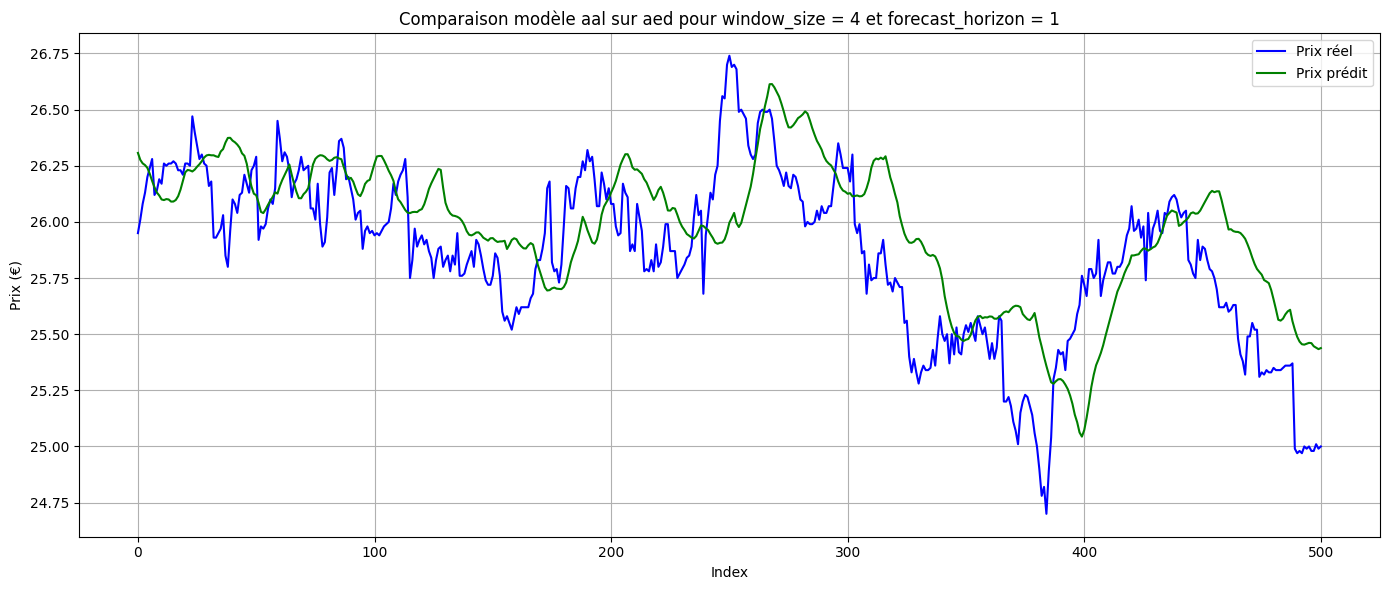

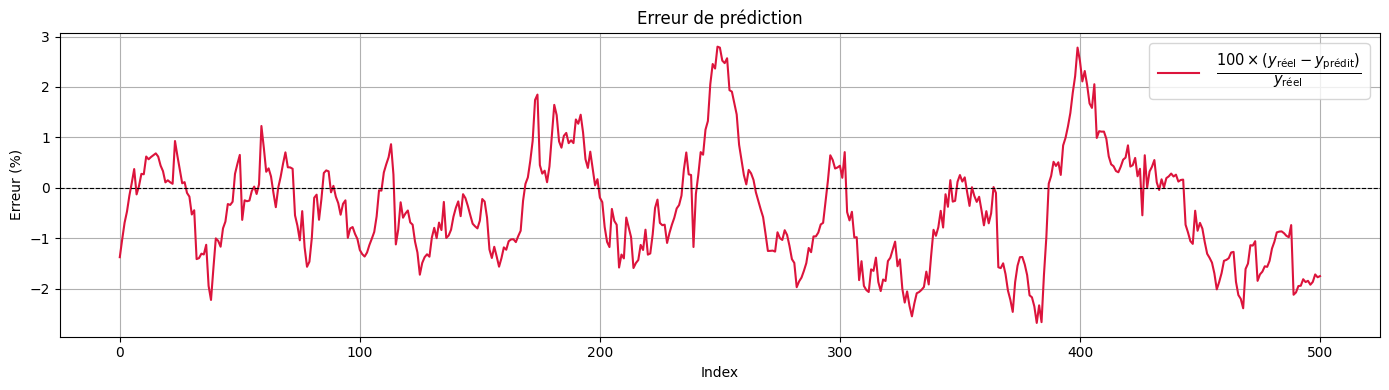

In [11]:
import matplotlib.pyplot as plt

results = {}

# Prédictions
y_pred_scaled = model.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_scaled)

# Calcul de l'erreur en pourcentage
percentage_errors = 100 * (y_test_real.ravel() - y_pred.ravel()) / y_test_real.ravel()
print(np.mean(percentage_errors))

# --------- FIGURE 1 : Prix réel vs prédit ---------
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred, label="Prix prédit", color="green")
plt.title("Comparaison modèle aal sur aed pour window_size = 4 et forecast_horizon = 1")
plt.xlabel("Index")
plt.ylabel("Prix (€)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# --------- FIGURE 2 : Erreur de prédiction en % ---------
plt.figure(figsize=(14, 4))
plt.plot(
    percentage_errors,
    label=r"$\frac{100 \times (y_{\mathrm{réel}} - y_{\mathrm{prédit}})}{y_{\mathrm{réel}}}$",
    color="crimson"
)
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur de prédiction")
plt.xlabel("Index")
plt.ylabel("Erreur (%)")
plt.legend(fontsize=15)
plt.grid(True)
plt.tight_layout()

plt.show()

# Jsp ce que c'est

In [ ]:
# Autre fonction de perte

# 2. Reconstruction du modèle
def build_model():
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window_size, num_features)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    return model

# Changer le delta permet d'ajuster la fonction de perte en fonction de notre situation
def huber_loss(y_true, y_pred, delta=1):
    error = y_true - y_pred
    is_small_error = tf.abs(error) < delta
    small_error_loss = 0.5 * tf.square(error)
    big_error_loss = delta * (tf.abs(error) - 0.5 * delta)
    return tf.reduce_mean(tf.where(is_small_error, small_error_loss, big_error_loss))

# 3. Création et compilation du modèle
model = build_model()
model.compile(optimizer=Adam(0.001), loss=huber_loss, metrics=['mae'])

model.compile(optimizer=Adam(0.001), loss=huber_loss, metrics=['mae'])

# Entraînement
history_huber = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.2)

In [ ]:
import matplotlib.pyplot as plt

# Prédictions
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Calcul de l'erreur
errors = y_test_real.ravel() - y_pred.ravel()

# --------- FIGURE 1 : Prix réel vs prédit ---------
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred, label="Prix prédit", color="green")
plt.title("Prix de clôture : réel vs prédit")
plt.xlabel("Index")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------- FIGURE 2 : Erreur de prédiction ---------
plt.figure(figsize=(14, 4))
plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur entre la prédiction et la réalité")
plt.xlabel("Index")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Suggestions pour améliorer avec Huber :
Ajuste delta en fonction de la distribution des erreurs :

- Par exemple, calcule la médiane ou la moyenne des erreurs absolues sur un petit jeu de test, puis fixe delta autour de cette valeur (en échelle normalisée).
- Essaye plusieurs delta (0.1, 0.5, 1, 2) et compare.
- Augmente le nombre d’époques pour voir si ça s’améliore avec plus d’entraînement.
- Teste une normalisation plus adaptée (par exemple RobustScaler au lieu de MinMaxScaler) pour limiter l’effet des outliers.

On va tenter de modifier la médiane.

In [ ]:
def make_huber_loss(delta):
    def huber_loss_fn(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < delta
        small_error_loss = 0.5 * tf.square(error)
        big_error_loss = delta * (tf.abs(error) - 0.5 * delta)
        return tf.reduce_mean(tf.where(is_small_error, small_error_loss, big_error_loss))
    return huber_loss_fn

In [ ]:
predictions = {}
deltas = [0.1, 1.0, 5.0, 10.0]
histories = {}

for delta in deltas:
    print(f"\n🔧 Entraînement avec delta = {delta}")

    # Nouveau modèle à chaque fois
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window_size, num_features)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])

    # Compiler avec Huber Loss personnalisée
    model.compile(optimizer=Adam(0.001),
                  loss=make_huber_loss(delta),
                  metrics=['mae'])

    # Entraînement
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    histories[delta] = history

    # Prédiction sur X_test
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_test_real = scaler_y.inverse_transform(y_test)

    predictions[delta] = (y_pred, y_test_real)

In [ ]:
import os
import matplotlib.pyplot as plt

output_dir = './Plots/LSTM/Modifier Delta'  # dossier courant

for delta in deltas:
    y_pred, y_test_real = predictions[delta]
    errors = y_test_real.ravel() - y_pred.ravel()

    # --------- FIGURE 1 ---------
    plt.style.use('dark_background')
    plt.figure(figsize=(14, 6))
    plt.plot(y_test_real, label="Prix réel", color="cyan")
    plt.plot(y_pred, label="Prix prédit", color="lime")
    plt.title(f"Réel vs Prédit (delta = {delta})", color="white")
    plt.xlabel("Index", color="white")
    plt.ylabel("Prix", color="white")
    plt.legend()
    plt.grid(True, color='gray', linestyle='--', linewidth=0.5)
    plt.tight_layout()

    filename1 = os.path.join(output_dir, f"plot_reel_vs_pred_delta_{delta}.jpg")
    plt.savefig(filename1, dpi=300)
    plt.show()

    # --------- FIGURE 2 ---------
    plt.style.use('dark_background')
    plt.figure(figsize=(14, 4))
    plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
    plt.axhline(0, color="white", linestyle="--", linewidth=0.8)
    plt.title(f"Erreur de prédiction (delta = {delta})", color="white")
    plt.xlabel("Index", color="white")
    plt.ylabel("Erreur", color="white")
    plt.legend()
    plt.grid(True, color='gray', linestyle='--', linewidth=0.5)
    plt.tight_layout()

    filename2 = os.path.join(output_dir, f"plot_erreur_delta_{delta}.jpg")
    plt.savefig(filename2, dpi=300)
    plt.show()

In [ ]:
for delta in deltas:
    history = histories[delta]
    plt.plot(history.history["loss"], label=f"Train (δ={delta})")
    plt.plot(history.history["val_loss"], linestyle='--', label=f"Val (δ={delta})")

plt.title("Courbes de perte pour différents δ (Huber)")
plt.xlabel("Épochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Test pour tracer le M2 supply

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

def liste_valeurs(ticker, period):
    if not isinstance(ticker, str):
        print("Un ticker est un code d'actif. Veuillez recommencer")
        return None
    
    stock = yf.Ticker(ticker)  # utiliser la variable, pas une chaîne littérale
    historical_data = stock.history(period=period)
    return list(historical_data['Close'])

# Exemple d'utilisation
data = liste_valeurs("btc-eur", "1y")
print(data)
range(len(data))

# Test pour voir si le modèle généralise

In [ ]:
import numpy as np
import pandas as pd
import datetime
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# === 1. Récupération du ticker utilisateur ===
ticker = input("Entrez le ticker de l'action ou crypto (ex: AAPL, TSLA, BTC-USD): ")

# 10 ans de données
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)

data = yf.download(ticker, start=start_date, end=end_date)
df = data.dropna()
df.sort_index(inplace=True)

# === 1b. Ajout des indicateurs techniques ===
# SMA sur 10 jours
df['SMA_10'] = df['Close'].rolling(10).mean()
# EMA sur 10 jours
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
# RSI sur 14 jours
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -1*delta.clip(upper=0)
roll_up = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
RS = roll_up / roll_down
df['RSI_14'] = 100 - (100 / (1 + RS))

df.dropna(inplace=True)  # supprimer les lignes avec NaN dues aux indicateurs

# === 2. Création des séquences multivariées ===
def create_windows(df, window_size=50, forecast_horizon=1, feature_cols=None):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][feature_cols].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

feature_cols = ["Open","High","Low","Close","Volume","SMA_10","EMA_10","RSI_14"]
num_features = len(feature_cols)
window_size = 20
forecast_horizon = 1

X, y = create_windows(df, window_size, forecast_horizon, feature_cols)

# === 4. Split train/test temporel ===
split = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]

# === 8. Prévisions sur le test set ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Décalage automatique selon forecast_horizon
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]

# === 9. Plotting ===
plt.figure(figsize=(14,6))
plt.plot(y_test_real, label="Prix réel", color="blue")
plt.plot(y_pred_aligned, label=f"Prix prédit (décalé {forecast_horizon} jours)", color="green")
plt.title(f"{ticker} - Prix réel vs prédit")
plt.xlabel("Index")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 10. Prédiction du prochain jour ===
last_window = X_scaled[-1].reshape(1, window_size, num_features)
pred_scaled = model.predict(last_window)
pred_close = scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0][0]

print(f"Prix prédit pour {ticker} dans {forecast_horizon} jours : {pred_close:.2f}")

# Test pour comprendre les strcutures

In [24]:
X, y = create_windows(df, 2, 3)
print(X)
print(X[:,:,0])
print(X[:,:,1])

[[[ 2.12096690e+00  2.13146380e+00  2.07148213e+00 ...  0.00000000e+00
    0.00000000e+00  6.21669941e-02]
  [ 2.09907352e+00  2.10837036e+00  2.01989675e+00 ... -3.73224112e-03
   -7.46448223e-04  6.21669941e-02]]

 [[ 2.09907352e+00  2.10837036e+00  2.01989675e+00 ... -3.73224112e-03
   -7.46448223e-04  6.21669941e-02]
  [ 2.05228824e+00  2.06488458e+00  2.02499636e+00 ... -7.28366429e-03
   -2.05389144e-03  6.21669941e-02]]

 [[ 2.05228824e+00  2.06488458e+00  2.02499636e+00 ... -7.28366429e-03
   -2.05389144e-03  6.21669941e-02]
  [ 2.06788261e+00  2.15125782e+00  2.06368377e+00 ... -9.39718948e-04
   -1.83105694e-03  6.21669941e-02]]

 ...

 [[ 2.74109985e+02  2.76700012e+02  2.72089996e+02 ...  5.44342768e+00
    5.57538576e+00  5.12651649e+00]
  [ 2.71049988e+02  2.75959991e+02  2.69600006e+02 ...  5.24446650e+00
    5.50920191e+00  5.13123983e+00]]

 [[ 2.71049988e+02  2.75959991e+02  2.69600006e+02 ...  5.24446650e+00
    5.50920191e+00  5.13123983e+00]
  [ 2.68820007e+02  2.7

In [25]:
window = df.iloc[0:2][["Open","High","Low","Close","Volume"]].values
print(window)
print(df)

[[2.12096690e+00 2.13146380e+00 2.07148213e+00 2.08917665e+00
  1.01851960e+09]
 [2.09907352e+00 2.10837036e+00 2.01989675e+00 2.04239035e+00
  8.91433200e+08]]
Price            Close        High         Low        Open      Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL        AAPL   
Date                                                                     
2005-11-28    2.089177    2.131464    2.071482    2.120967  1018519600   
2005-11-29    2.042390    2.108370    2.019897    2.099074   891433200   
2005-11-30    2.033993    2.064885    2.024996    2.052288   595674800   
2005-12-01    2.147359    2.151258    2.063684    2.067883   812893200   
2005-12-02    2.178249    2.181548    2.120366    2.167452   895762000   
...                ...         ...         ...         ...         ...   
2025-11-17  267.459991  270.489990  265.730011  268.820007    45018300   
2025-11-18  267.440002  270.709991  265.320007  269.989990    45677300   
2025-11-19  268.559998  2

# Money supply

In [ ]:
pip install pandas matplotlib requests

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dates
dates = pd.date_range(start="2000-01-01", end="2025-01-01", freq='M')

# Simuler des données M2 en USD pour différents pays
np.random.seed(42)
countries = ["US", "EU", "CN", "IN", "JP", "BR"]
data = {country: np.cumsum(np.random.rand(len(dates))*10 + 100) for country in countries}

# Créer DataFrame
df = pd.DataFrame(data, index=dates)

# Calculer M2 global
df['Global_M2'] = df.sum(axis=1)

# Offset (décalage en mois)
offset = 10
df['Global_M2_shifted'] = df['Global_M2'].shift(offset)

# Plot
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Global_M2_shifted'], color='blue', linewidth=2)
plt.title('Global (World) Money Supply M2 (simulé)')
plt.xlabel('Date')
plt.ylabel('M2 USD (simulé)')
plt.grid(True)

# Label sur la dernière valeur
last_value = df['Global_M2_shifted'].iloc[-1]/1e3  # en "k USD" pour l'exemple
plt.text(df.index[-1], df['Global_M2_shifted'].iloc[-1],
         f"Global M2: {last_value:.2f}k USD, Offset={offset}",
         color='white', backgroundcolor='blue')

plt.show()

# Test du modèle ChatGPT issu des recherches biblio

Entrez le ticker (ex: AAPL, BTC-USD):  aapl


Data head:
Price          Close      High       Low      Open      Volume
Ticker          AAPL      AAPL      AAPL      AAPL        AAPL
Date                                                          
2005-11-28  2.089177  2.131464  2.071482  2.120967  1018519600
2005-11-29  2.042390  2.108370  2.019897  2.099074   891433200
2005-11-30  2.033993  2.064885  2.024996  2.052288   595674800
2005-12-01  2.147359  2.151258  2.063684  2.067883   812893200
2005-12-02  2.178249  2.181548  2.120366  2.167452   895762000
X.shape, y.shape: (5022, 7, 11) (5022, 1)


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 7, 11)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 7, 32)          │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 7, 64)          │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 7, 256)         │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 7, 128)         │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention_2            │ (None, 128)            │        16,640 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 415,233 (1.58 MB)

 Trainable params: 415,041 (1.58 MB)

 Non-trainable params: 192 (768.00 B)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step


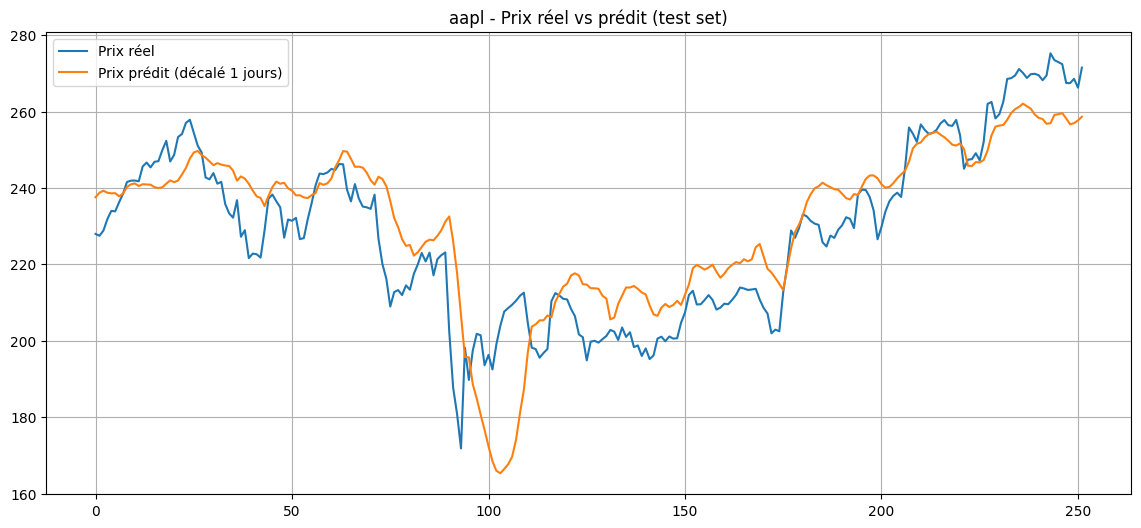

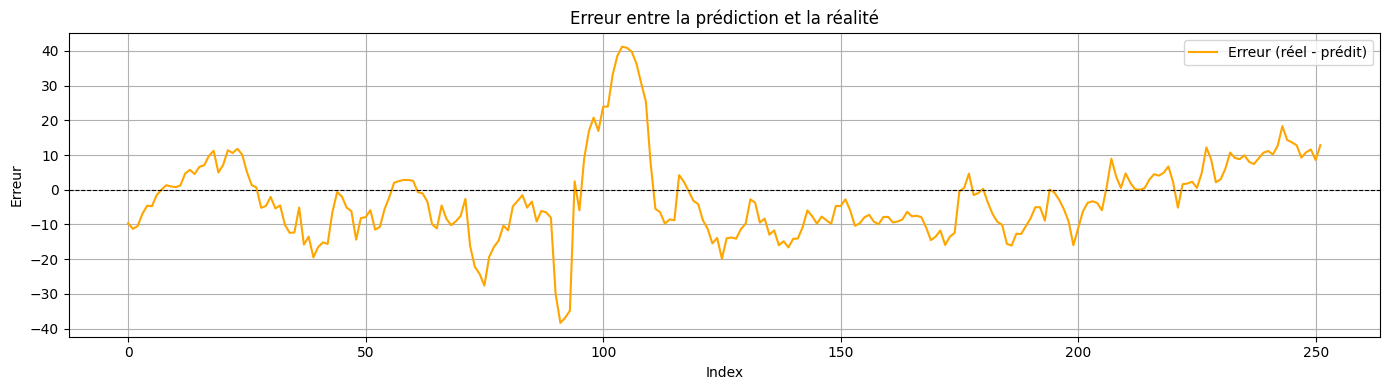

ValueError: X has 1 features, but MinMaxScaler is expecting 7 features as input.

In [23]:
"""
CNN + BiLSTM + Temporal Attention for stock price prediction
With selected technical indicators
Executable on Kaggle
"""
import random
from tensorflow.keras import layers, Model, Sequential, regularizers
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Bidirectional, LSTM, Dense

# --------------------------
# Reproducibility
# Ce bloc fixe tous les générateurs de nombres aléatoires du code (Python, NumPy, TensorFlow) 
# pour que ton entraînement et tes prédictions soient reproduisibles d’une exécution à l’autre.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# --------------------------
# 1. Download data
ticker = input("Entrez le ticker (ex: AAPL, BTC-USD): ").strip() or "AAPL"
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=20*365)
df = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()
df.sort_index(inplace=True)
print("Data head:")
print(df.head())

# SMA20 – Simple Moving Average sur 20 jours, capture la tendance moyenne.
# EMA20 – Exponentially Weighted MA, plus réactif aux variations récentes.
# RSI14 – Relative Strength Index, indique conditions de surachat/survente.
# MACD & MACD_signal – Capture momentum et changement de tendance.
# ATR14 – Average True Range, mesure la volatilité récente.

# --------------------------
# 2. Add selected technical indicators
df['SMA20'] = df['Close'].rolling(20).mean().fillna(method='bfill')
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()
# RSI14
delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / (avg_loss + 1e-10)
df['RSI14'] = 100 - (100 / (1 + rs))
# MACD
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
# ATR14
high_low = df['High'] - df['Low']
high_close = (df['High'] - df['Close'].shift()).abs()
low_close  = (df['Low'] - df['Close'].shift()).abs()
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['ATR14'] = tr.rolling(14).mean()

df.fillna(method='bfill', inplace=True)

# --------------------------
# 3. Define features and create windows
features = ["Open","High","Low","Close","Volume","SMA20","EMA20","RSI14","MACD","MACD_signal","ATR14"]
num_features = len(features)
window_size = 7
forecast_horizon = 1

def create_windows(df, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        window = df.iloc[i:i+window_size][features].values
        target = df.iloc[i + window_size + forecast_horizon - 1]["Close"]
        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

X, y = create_windows(df, window_size, forecast_horizon)
print("X.shape, y.shape:", X.shape, y.shape)

# --------------------------
# 4. Scale data
split = int(0.95 * len(X))
X_train_raw, X_test_raw = X[:split], X[split:]
y_train_raw, y_test_raw = y[:split], y[split:]

scalers_X = {}
X_train_scaled = np.zeros_like(X_train_raw, dtype=np.float32)
X_test_scaled  = np.zeros_like(X_test_raw, dtype=np.float32)
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    scalers_X[i].fit(X_train_raw[:,:,i])
    X_train_scaled[:,:,i] = scalers_X[i].transform(X_train_raw[:,:,i])
    X_test_scaled[:,:,i] = scalers_X[i].transform(X_test_raw[:,:,i])

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw.reshape(-1,1)).reshape(-1)
y_test_scaled  = scaler_y.transform(y_test_raw.reshape(-1,1)).reshape(-1)

X_train, X_test, y_train, y_test = X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled

# --------------------------
# 5. Build model: CNN -> BiLSTM -> Temporal Attention -> MLP
# Le Temporal Attention regarde la séquence de jours, décide quels jours 
# sont importants, et résume tout ça en un vecteur clé pour la prédiction finale.
class TemporalAttention(layers.Layer):
    def __init__(self, units=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
    def build(self, input_shape):
        time_steps, feature_dim = input_shape[1], input_shape[2]
        self.units = self.units or feature_dim
        self.W = self.add_weight(shape=(feature_dim, self.units), initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(self.units,), initializer='zeros', trainable=True)
        self.v = self.add_weight(shape=(self.units,1), initializer='glorot_uniform', trainable=True)
        super().build(input_shape)
    def call(self, inputs):
        u = tf.tensordot(inputs, self.W, axes=[[2],[0]]) + self.b
        u = tf.tanh(u)
        score = tf.tensordot(u, self.v, axes=[[2],[0]])
        score = tf.squeeze(score, axis=-1)
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(inputs * tf.expand_dims(weights,-1), axis=1)
        return context

def build_model(window_size, num_features):
    inp = Input(shape=(window_size,num_features))
    x = Conv1D(32,3,padding='same',activation='gelu')(inp)
    x = BatchNormalization()(x)
    x = Conv1D(64,5,padding='same',activation='gelu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Bidirectional(LSTM(128,return_sequences=True))(x)
    x = Dropout(0.25)(x)
    x = Bidirectional(LSTM(64,return_sequences=True))(x)
    x = Dropout(0.25)(x)
    context = TemporalAttention()(x)
    h = Dense(128, activation='gelu')(context)
    h = Dropout(0.3)(h)
    h = Dense(64, activation='gelu')(h)
    h = Dropout(0.2)(h)
    out = Dense(1, activation='linear')(h)
    return Model(inputs=inp, outputs=out)

model = build_model(window_size, num_features)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=tf.keras.losses.Huber(),
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

model.summary()

# --------------------------
# 6. Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6)

# --------------------------
# 7. Train
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=200, batch_size=64,
                    callbacks=[early_stop, reduce_lr],
                    verbose=0)

# --------------------------
# 8. Predict and inverse scale
y_pred_scaled = model.predict(X_test).reshape(-1)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).reshape(-1)
y_test_real = scaler_y.inverse_transform(y_test.reshape(-1,1)).reshape(-1)

y_pred_aligned = np.full_like(y_test_real, np.nan, dtype=np.float32)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]

plt.figure(figsize=(14,6))
plt.plot(y_test_real, label="Prix réel")
plt.plot(y_pred_aligned, label=f"Prix prédit (décalé {forecast_horizon} jours)")
plt.title(f"{ticker} - Prix réel vs prédit (test set)")
plt.legend()
plt.grid(True)
plt.show()

# Calcul de l'erreur
errors = y_test_real.ravel() - y_pred_aligned.ravel()

# --------- FIGURE 2 : Erreur de prédiction ---------
plt.figure(figsize=(14, 4))
plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur entre la prédiction et la réalité")
plt.xlabel("Index")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------
# 9. Next-day prediction
last_window = X_scaled[-1].reshape(1, window_size, num_features)
pred_scaled = model.predict(last_window)
pred_close = scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0][0]

print(f"Prix prédit pour {ticker} dans {forecast_horizon} jours : {pred_close:.2f}")

# --------------------------
# 10. Optional: directional accuracy
dir_true = np.sign(y_test_real[1:] - y_test_real[:-1])
dir_pred = np.sign(y_pred_aligned[1:] - y_test_real[:-1])
mask = ~np.isnan(dir_pred)
acc_dir = np.mean(dir_true[mask] == dir_pred[mask])
print(f"Directional accuracy (approx) on test: {acc_dir*100:.2f}%")

# Simple GRU

Entrez le ticker (ex: AAPL, BTC-USD):  aapl


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_22 (GRU)                    │ (None, 20, 128)        │        54,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_23 (GRU)                    │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,457 (357.25 KB)

 Trainable params: 91,457 (357.25 KB)

 Non-trainable params: 0 (0.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


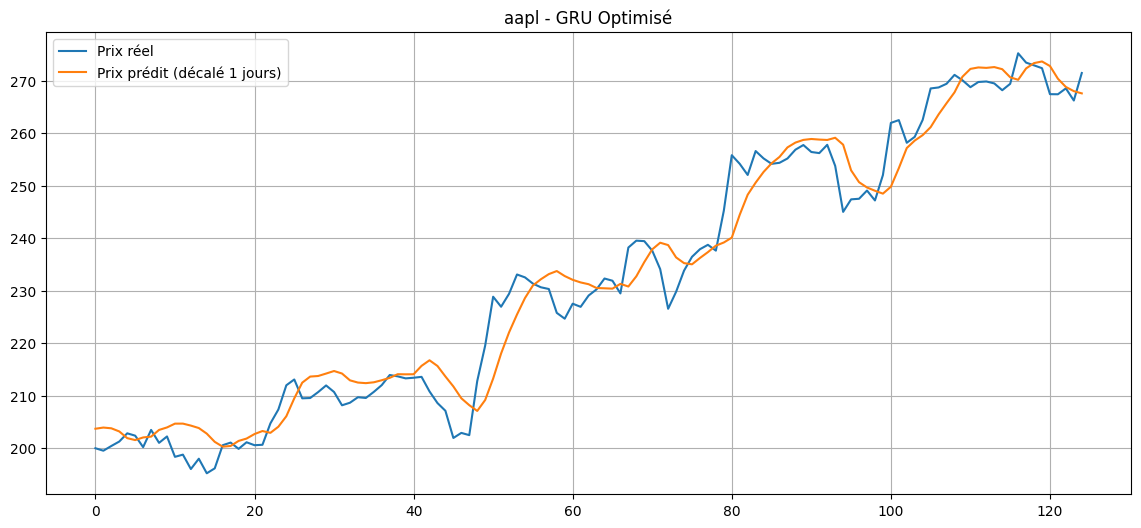

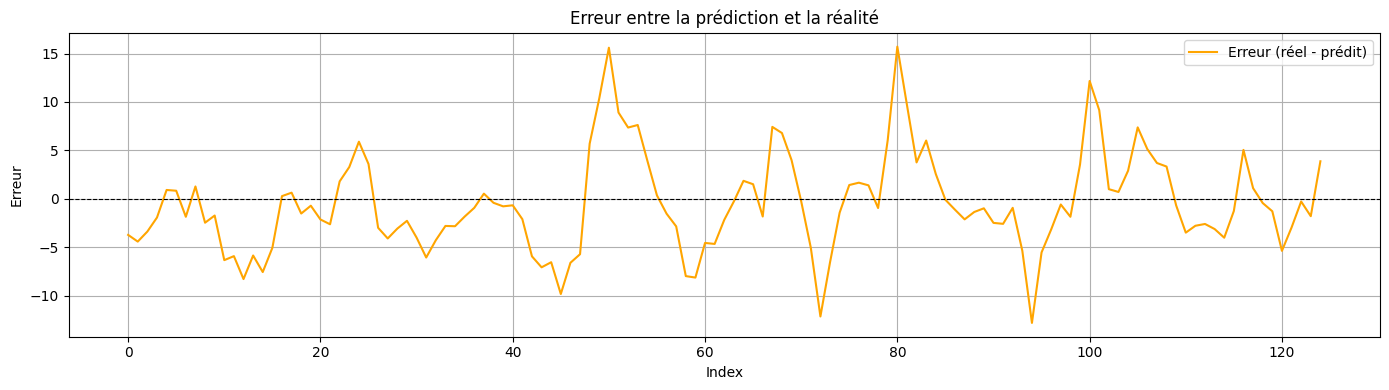

ValueError: cannot reshape array of size 160 into shape (1,20,11)

In [29]:
# -*- coding: utf-8 -*-
"""
Optimized GRU for stock price prediction
With selected technical indicators
"""

import datetime
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import random

# --------------------------
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# --------------------------
# 1. Download data
ticker = input("Entrez le ticker (ex: AAPL, BTC-USD): ").strip() or "AAPL"
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)
df = yf.download(ticker, start=start_date, end=end_date, progress=False).dropna()
df.sort_index(inplace=True)

# --------------------------
# 2. Add key technical indicators
df['SMA20'] = df['Close'].rolling(20).mean().fillna(method='bfill')
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

# RSI14
delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / (avg_loss + 1e-10)
df['RSI14'] = 100 - (100 / (1 + rs))

# MACD
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# ATR14
high_low = df['High'] - df['Low']
high_close = (df['High'] - df['Close'].shift()).abs()
low_close  = (df['Low'] - df['Close'].shift()).abs()
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['ATR14'] = tr.rolling(14).mean()

df.fillna(method='bfill', inplace=True)

# --------------------------
# 3. Features and windows
features = ["Open","High","Low","Close","Volume","SMA20","EMA20","RSI14","MACD","MACD_signal","ATR14"]
num_features = len(features)
window_size = 20
forecast_horizon = 1

def create_windows(df, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(df) - window_size - forecast_horizon + 1):
        X.append(df[features].iloc[i:i+window_size].values)
        y.append(df["Close"].iloc[i + window_size + forecast_horizon - 1])
    return np.array(X), np.array(y)

X, y = create_windows(df, window_size, forecast_horizon)

# --------------------------
# 4. Scale data
split = int(0.95 * len(X))
X_train_raw, X_test_raw = X[:split], X[split:]
y_train_raw, y_test_raw = y[:split], y[split:]

scalers_X = {}
X_train_scaled = np.zeros_like(X_train_raw, dtype=np.float32)
X_test_scaled  = np.zeros_like(X_test_raw, dtype=np.float32)
for i in range(num_features):
    scalers_X[i] = MinMaxScaler()
    scalers_X[i].fit(X_train_raw[:,:,i])
    X_train_scaled[:,:,i] = scalers_X[i].transform(X_train_raw[:,:,i])
    X_test_scaled[:,:,i] = scalers_X[i].transform(X_test_raw[:,:,i])

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw.reshape(-1,1)).reshape(-1)
y_test_scaled  = scaler_y.transform(y_test_raw.reshape(-1,1)).reshape(-1)

X_train, X_test, y_train, y_test = X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled

# --------------------------
# 5. Build GRU model
model = Sequential([
    GRU(128, return_sequences=True, input_shape=(window_size, num_features)),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='mse',
              metrics=['mae'])
model.summary()

# --------------------------
# 6. Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# --------------------------
# 7. Train
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=100, batch_size=32,
                    callbacks=[early_stop, reduce_lr],
                    verbose=0)

# --------------------------
# 8. Predict
y_pred_scaled = model.predict(X_test).reshape(-1)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).reshape(-1)
y_test_real = scaler_y.inverse_transform(y_test.reshape(-1,1)).reshape(-1)

# Décalage automatique selon forecast_horizon
y_pred_aligned = np.full_like(y_test_real, np.nan)
if forecast_horizon <= len(y_pred):
    y_pred_aligned[forecast_horizon-1:] = y_pred[:len(y_pred)-forecast_horizon+1]


plt.figure(figsize=(14,6))
plt.plot(y_test_real, label="Prix réel")
plt.plot(y_pred_aligned, label=f"Prix prédit (décalé {forecast_horizon} jours)")
plt.title(f"{ticker} - GRU Optimisé")
plt.legend()
plt.grid(True)
plt.show()

# Calcul de l'erreur
errors = y_test_real.ravel() - y_pred_aligned.ravel()

# --------- FIGURE 2 : Erreur de prédiction ---------
plt.figure(figsize=(14, 4))
plt.plot(errors, label="Erreur (réel - prédit)", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Erreur entre la prédiction et la réalité")
plt.xlabel("Index")
plt.ylabel("Erreur")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------
# 9. Next-day prediction
last_window = X_scaled[-1].reshape(1, window_size, num_features)
pred_scaled = model.predict(last_window)
pred_close = scaler_y.inverse_transform(pred_scaled.reshape(-1,1))[0][0]

print(f"Prix prédit pour {ticker} dans {forecast_horizon} jours : {pred_close:.2f}")